In [22]:
# %% [Célula 1] Imports e Configurações
import os
import glob
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import List, Dict, Optional, Tuple, Sequence

# Configurações de avisos e estilo
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Configuração global do Matplotlib (mantendo o estilo original)
plt.rcParams.update({
    # --- Tamanhos de Fonte Reais (IEEE) ---
    'font.size': 10,              # Tamanho base (igual ao texto do artigo)
    'axes.labelsize': 10,         # Títulos dos eixos (Time, Reliability...)
    'legend.fontsize': 8,         # Legenda (igual ao caption do LaTeX)
    'xtick.labelsize': 8,         # Números dos eixos
    'ytick.labelsize': 8,         # Números dos eixos
    'axes.titlesize': 10,         # Título do gráfico (se houver)
    
    # --- Espessuras de Linha (Ajustadas para figura pequena) ---
    'lines.linewidth': 1.5,       # Mais fino, pois a figura é menor
    'axes.linewidth': 0.8,        # Bordas dos eixos
    'grid.linewidth': 0.5,        # Grade mais sutil
    'hatch.linewidth': 0.5,
    
    # --- Fontes ---
    'font.family': 'serif',       # Combina com Times New Roman do IEEE
    'text.usetex': False          # Se True, usa o renderizador LaTeX (opcional, mas fica bonito)
})

def setup_ieee_fig(ratio=0.6):
    """
    Cria uma figura com largura de 3.5 polegadas (coluna IEEE).
    ratio: altura / largura (padrão 0.6 para retângulo áureo aproximado)
    """
    width = 3.5  # polegadas
    height = width * ratio
    return plt.subplots(figsize=(width, height))

In [23]:
# %%
# %% [Célula 2] Configurações e Constantes

# Diretório base dos resultados
RESULTS_DIR = '../../results/results_flows*/*'

# Métricas que serão lidas ou calculadas
METRICAS_COLETA = [
    'tempo', 'cpu_utilization', 'gpu_utilization', 'cache_utilization',
    'bandwidth_utilization', 'bandwidth_utilization_per_flow',
    'success', 'latency', 'decision_time_ms', 'running_sfcs',
    'cpu_saved', 'shared_vnfs', 'shared_vnfs_per_flow',
    'cpu_per_flow', 'gpu_per_flow', 'cache_per_flow',
    "total_energy_consumption", "energy_consumption_per_flow",
    "jain_fairness_latencia_por_sessao", "acceptance_rate",
    "queue_time", "jain_cpu", "jain_gpu", "jain_bw", "avg_sfc_reliability"
]

# Mapeamento: Nome na Pasta -> Nome no Gráfico
NOME_ALGORITMOS_MAP = {
    'g': 'Greedy',
    'ga': 'OSCIM',
    'msf': 'MSF',
    'goku': 'OSCIM',
    'vegeta': 'IMSCO',
    'musfico': 'MuSFiCO',
    'greedyb': 'GreedyB',
    'kuririnPPO': 'INOMMUS',
    'kuririnMaskablePPO': 'INOMMUS',
    'darsppo': 'DARSPPO',
    'darsppoMaskablePPO': 'DA-RSPPO',
    'hephaestus': 'hephaestus',
    'hephaestusMaskablePPO': 'Hephaestus',
    'REPLICMASKABLEPPO': 'RELIC',
    'DRLMASKABLEPPO': 'HDRLB'
}

# Cores específicas para cada algoritmo (Consistência visual) - ATUALIZADO TONS DE VERDE
CORES_ALGORITMOS = {
    "INOMMUS": "#1f77b4",     
    "DA-RSPPO": "#ff7f0e",
    "RELIC": "#90BE6D",       # Verde Claro/Mudo (Padrão Fig 4)
    "Hephaestus": "#2ca02c",  
    "OSCIM": "#d62728",       
    "GreedyB": "#9467bd",     
    "IMSCO": "#8c564b",
    "HDRLB": "#4D774E"        # Verde Escuro/Mudo (Padrão Fig 4)
}

# Padrões de hachura (textura das barras)
HATCH_PATTERNS = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']

In [24]:
# %% [Célula 3] Funções de Processamento de Dados

def jain_fairness_index(x):
    """Calcula o índice de justiça de Jain para uma série."""
    x = x.dropna()
    n = len(x)
    if n == 0: return np.nan
    sum_sq = (x * x).sum()
    if sum_sq == 0: return 1.0
    return (x.sum() ** 2) / (n * sum_sq)

def enriquecer_dataframe(df):
    """Adiciona colunas calculadas ao DataFrame."""
    df = df.copy()

    # 1. Jain Fairness por Sessão
    if 'sfc_id' in df.columns and 'latency' in df.columns:
        df['session_id'] = df['sfc_id'].str.split('_').str[-1]
        df['jain_fairness_latencia_por_sessao'] = df.groupby('session_id')['latency'].transform(jain_fairness_index)
        df['jain_fairness_latencia_por_sessao'] = df['jain_fairness_latencia_por_sessao'].fillna(0)
        df.drop(columns=['session_id'], inplace=True)

    # 2. Métricas "Por Fluxo" (Divisão segura por running_sfcs)
    for metric, new_col in [
        ('total_energy_consumption', 'energy_consumption_per_flow'),
        ('bandwidth_utilization', 'bandwidth_utilization_per_flow'),
        ('shared_vnfs', 'shared_vnfs_per_flow')
    ]:
        if metric in df.columns:
            df[new_col] = np.where(df['running_sfcs'] == 0, 0.0, df[metric] / df['running_sfcs'])

    # 3. QoS Score
    if 'latency' in df.columns and 'success' in df.columns:
        df['pontuacao_latencia'] = df['latency'].apply(lambda x: 0 if pd.isna(x) else (-1 if x > 6 else 2))
        df['pontuacao_success'] = df['success'] * 10
        df['QoS'] = df['pontuacao_latencia'] + df['pontuacao_success']
    
    return df

In [25]:
# %% [Célula 4] Coleta de Dados

def coletar_dados(diretorio_pattern):
    data_frames = []
    diretorios = glob.glob(diretorio_pattern)
    
    print(f"Encontrados {len(diretorios)} diretórios de simulação.")

    for alg_dir in diretorios:
        # Extrair nome do algoritmo do caminho
        dir_name = os.path.basename(os.path.normpath(alg_dir))
        raw_name = dir_name.split('_')[0]
        # Tratamento para caminhos Windows/Linux misturados
        if '\\' in raw_name: raw_name = raw_name.split('\\')[-1]
        
        alg_name = NOME_ALGORITMOS_MAP.get(raw_name, raw_name)
        
        files = glob.glob(os.path.join(alg_dir, "*.csv"))
        # print(f"Lendo {alg_name}: {len(files)} arquivos.")

        for file in files:
            try:
                df = pd.read_csv(file)
                
                # Ajustes iniciais e Filtros
                df = enriquecer_dataframe(df)
                
                # Calcular tempo relativo (segundos desde o início)
                start_time = df['timestamp'].values[0]
                df['tempo'] = (df['timestamp'] - start_time).astype(int)
                
                # Verificar se a simulação foi válida (> 100s)
                if df['tempo'].max() < 100:
                    continue

                # Sucesso acumulativo (média expandida)
                df['success'] = df['success'].expanding().mean()

                # Agrupamento temporal (segundo a segundo) e preenchimento (ffill)
                df_grouped = df.groupby('tempo', as_index=False).mean(numeric_only=True)
                max_time = df_grouped['tempo'].max()
                
                # Reindexar para garantir continuidade temporal
                idx_completo = pd.RangeIndex(start=0, stop=max_time + 1, name='tempo')
                df_final = df_grouped.set_index('tempo').reindex(idx_completo).ffill().reset_index()
                
                # Recorte de 1000 segundos (padrão do paper)
                df_final = df_final.iloc[0:1000]
                df_final['algorithm'] = alg_name
                
                data_frames.append(df_final)

            except Exception as e:
                print(f"Erro ao ler {file}: {e}")
                continue

    if data_frames:
        big_df = pd.concat(data_frames, ignore_index=True)
        # Normalizações globais finais (/100)
        cols_to_normalize = ['acceptance_rate', 'cpu_per_flow', 'gpu_per_flow', 'cache_per_flow']
        for col in cols_to_normalize:
            if col in big_df.columns:
                big_df[col] = big_df[col] / 100
        return big_df
    else:
        return pd.DataFrame()

In [26]:
# %% [Célula 5] Executar Carregamento

print("Iniciando coleta...")
big_data = coletar_dados(RESULTS_DIR)

# Filtro final: Remover período de aquecimento (< 200s)
if not big_data.empty:
    print(f"Total de linhas carregadas: {len(big_data)}")
    big_data = big_data[big_data['tempo'] >= 0].copy()
    print(f"Linhas após filtro de aquecimento (>= 200s): {len(big_data)}")
else:
    print("Nenhum dado encontrado! Verifique o caminho RESULTS_DIR.")

Iniciando coleta...
Encontrados 3 diretórios de simulação.
Total de linhas carregadas: 61897
Linhas após filtro de aquecimento (>= 200s): 61897


In [27]:
# %% [Célula 6] Funções de Plotagem

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# %%
# %% [Célula 6] Funções de Plotagem

def create_boxplot(df, y_col, title, filename=None, show_outliers=False, steps=200, ylim=None, yticks=None):
    """Cria boxplot temporal."""
    df_plot = df.copy()
    df_plot['window'] = (df_plot['tempo'] // steps + 1) * steps

    windows = sorted(df_plot['window'].unique())
    algs = sorted(
        df_plot['algorithm'].unique(),
        key=lambda x: list(CORES_ALGORITMOS.keys()).index(x)
        if x in CORES_ALGORITMOS else 999
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    group_width = 0.8
    box_width = group_width / len(algs)
    positions_base = np.arange(len(windows))

    legend_handles = []

    for i, alg in enumerate(algs):
        color = CORES_ALGORITMOS.get(alg, plt.cm.tab10(i))
        hatch = HATCH_PATTERNS[i % len(HATCH_PATTERNS)]

        alg_data = df_plot[df_plot['algorithm'] == alg]
        data_per_window = [
            alg_data[alg_data['window'] == w][y_col].dropna().values
            for w in windows
        ]

        offset = (i - len(algs) / 2) * box_width + box_width / 2
        positions = positions_base + offset

        flier_props = dict(
            marker='o',
            markersize=3,
            markerfacecolor=color,
            markeredgecolor=color,
            alpha=0.7
        )

        bp = ax.boxplot(
            data_per_window,
            positions=positions,
            widths=box_width * 0.9,
            patch_artist=True,
            showfliers=show_outliers,
            boxprops=dict(facecolor=color, hatch=hatch, alpha=0.8, linewidth=1.2),
            medianprops=dict(color='black', linewidth=1.8),
            flierprops=flier_props if show_outliers else dict(marker='')
        )

        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_hatch(hatch)
            patch.set_edgecolor('black')

        legend_handles.append(
            Patch(facecolor=color, edgecolor='black', hatch=hatch, alpha=0.8, label=alg)
        )

    # Labels em negrito
    ax.set_ylabel(title, fontsize=26, fontweight='bold')
    ax.set_xlabel("Time (s)", fontsize=26, fontweight='bold')

    ax.set_xticks(positions_base)
    ax.set_xticklabels(windows, fontsize=20, fontweight='bold')

    ax.tick_params(axis='y', labelsize=20)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    # 2. ADICIONE ESTAS DUAS LINHAS AQUI, logo antes do ax.grid:
    if ylim is not None:
        ax.set_ylim(ylim)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=0.8)

    leg = ax.legend(
        handles=legend_handles,
        loc='lower right',
        ncol=1,
        frameon=True,
        handlelength=2.2,
        fontsize=20,          # <-- Ajustado de 16 para 20
        facecolor='white',
        framealpha=0.8
    )

    for text in leg.get_texts():
        text.set_fontweight('bold')

    # --- Ajuste na Borda da Legenda (Movido para ANTES do savefig) ---
    leg.get_frame().set_linewidth(2.0)  # <-- Ajustado de 1.5 para 2.0
    leg.get_frame().set_edgecolor('black')
    # -----------------------------------------------------------------

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0)

    plt.show()


def create_binned_boxplot(df, x_col, y_col, x_label, y_label, bin_size=10, filename=None):
    """
    Cria boxplot agrupado por bins de uma métrica X.
    """
    df_plot = df.copy()
    
    df_plot['x_scaled'] = df_plot[x_col] * 100
    df_plot['bin'] = (np.ceil(df_plot['x_scaled'] / bin_size) * bin_size).astype(int)
    
    bins = sorted(df_plot['bin'].unique())
    algs = sorted(df_plot['algorithm'].unique()) 
    
    fig, ax = plt.subplots(figsize=(9.8, 6.2))
    
    box_width = 0.8 / len(algs)
    positions_base = np.arange(len(bins))
    legend_handles = []

    for i, alg in enumerate(algs):
        color = CORES_ALGORITMOS.get(alg, plt.cm.tab10(i))
        hatch = HATCH_PATTERNS[i % len(HATCH_PATTERNS)]
        
        alg_data = df_plot[df_plot['algorithm'] == alg]
        data_per_bin = [
            alg_data[alg_data['bin'] == b][y_col].dropna().values
            for b in bins
        ]
        
        offset = (i - len(algs)/2) * box_width + box_width/2

        bp = ax.boxplot(
            data_per_bin,
            positions=positions_base + offset,
            widths=box_width*0.9,
            patch_artist=True,
            showfliers=True,
            boxprops=dict(facecolor=color, hatch=hatch, alpha=0.5),
            medianprops=dict(color='black'),
            flierprops=dict(marker='o', markersize=3, markerfacecolor=color, alpha=0.7)
        )
        
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_hatch(hatch)
            
        legend_handles.append(
            Patch(facecolor=color, hatch=hatch, alpha=0.5, label=alg)
        )

    ax.set_ylabel(y_label, fontsize=26, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=26, fontweight='bold')

    ax.set_xticks(positions_base)
    ax.set_xticklabels([str(b) for b in bins], fontsize=20, fontweight='bold')

    ax.tick_params(axis='y', labelsize=20)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    ax.grid(axis='y', linestyle='--', alpha=0.5)

    leg = ax.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=min(4, len(algs)),
        frameon=True,
        fontsize=16
    )

    for text in leg.get_texts():
        text.set_fontweight('bold')
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0)

    plt.show()


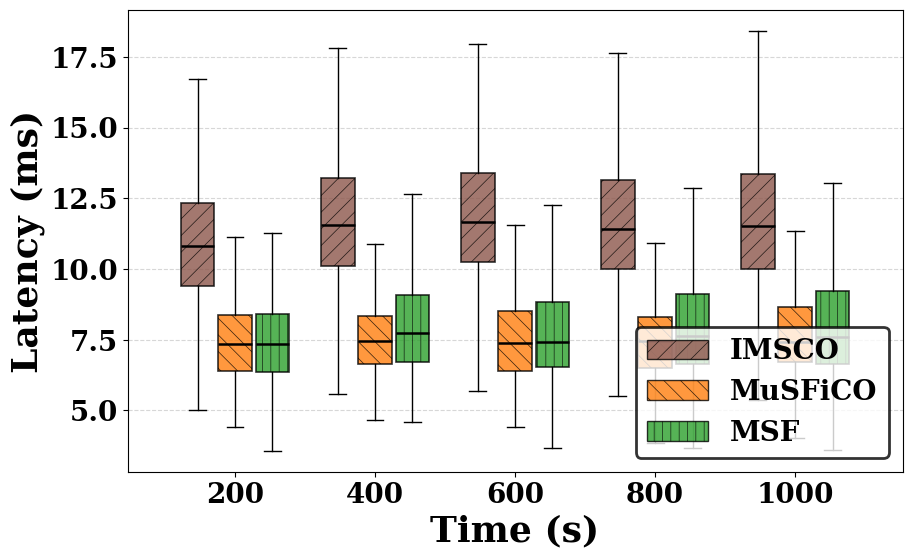

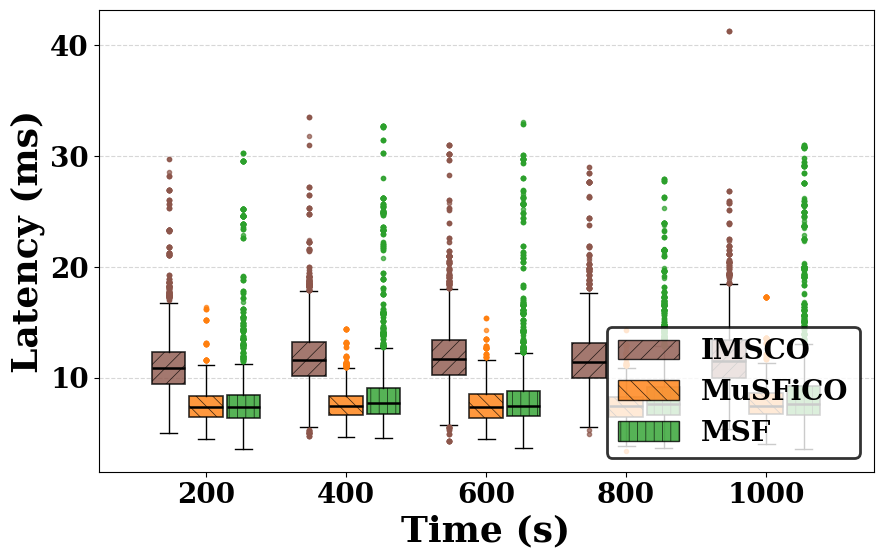

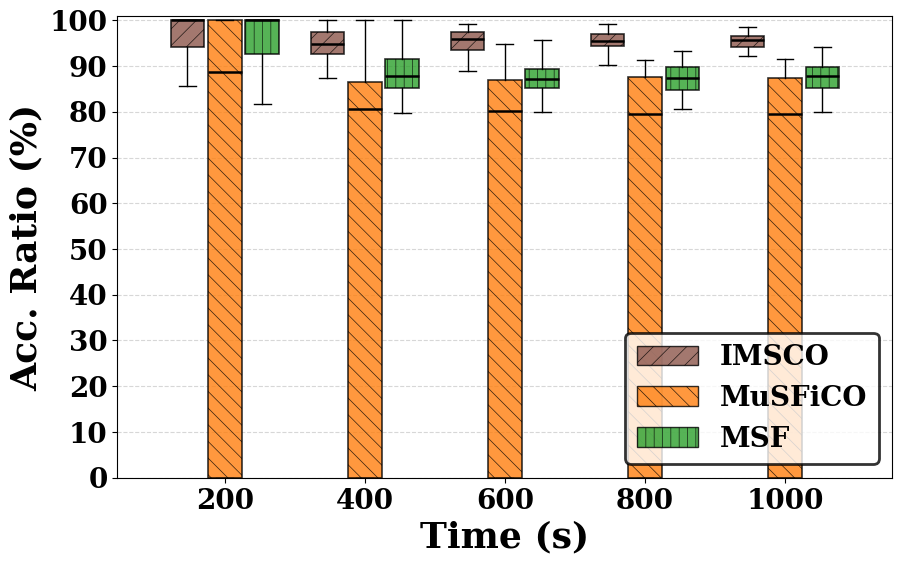

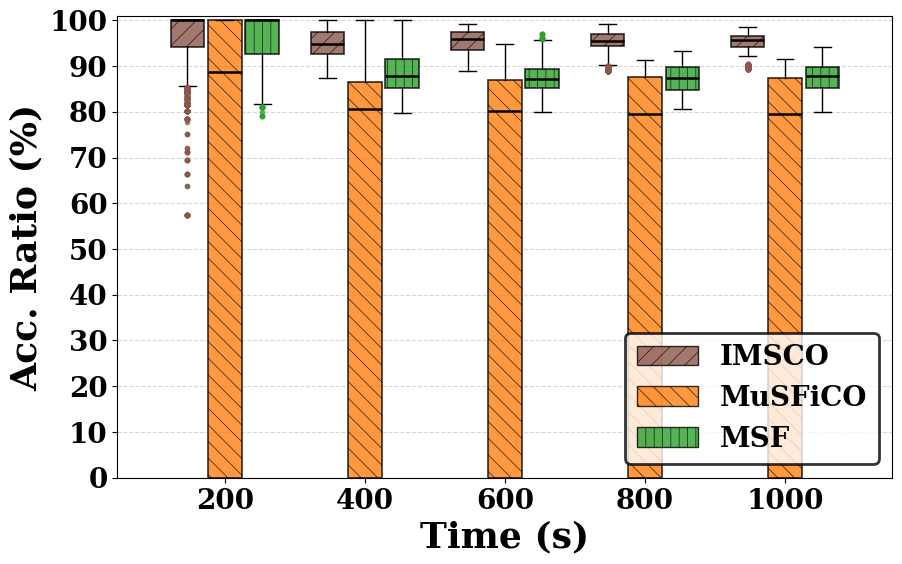

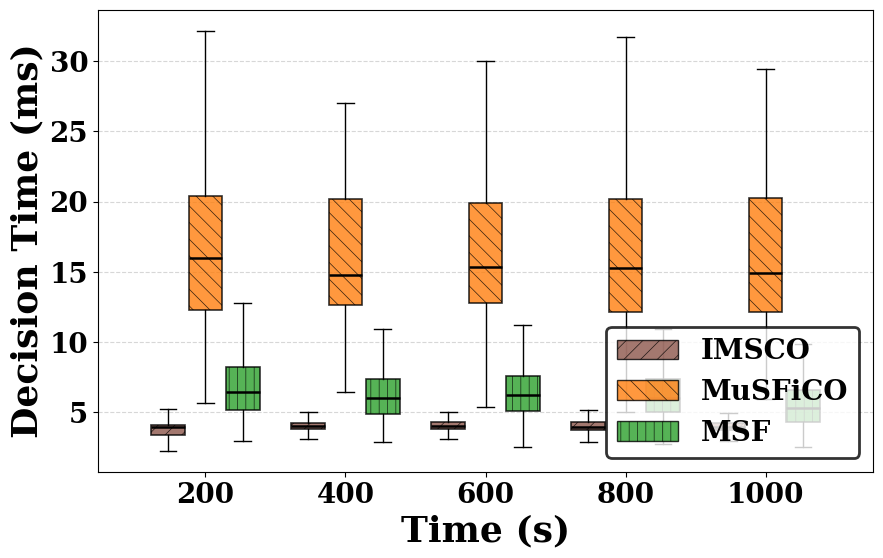

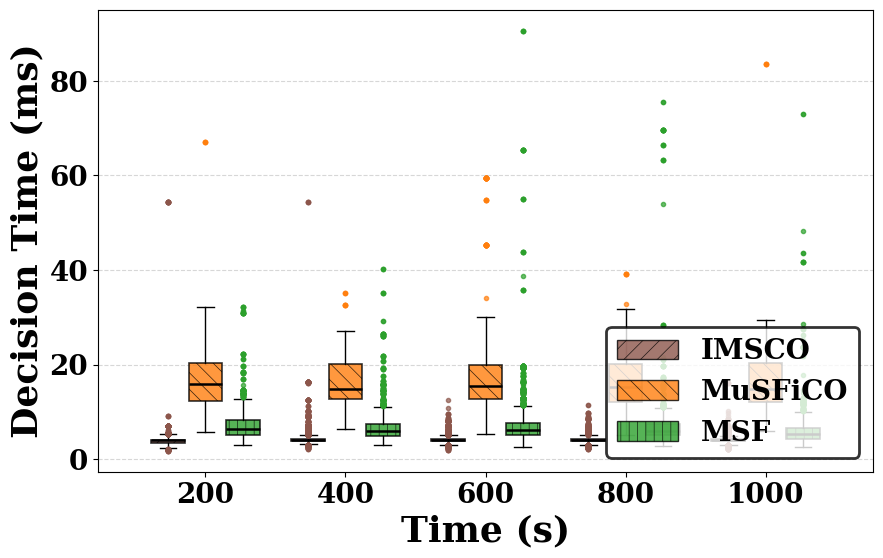

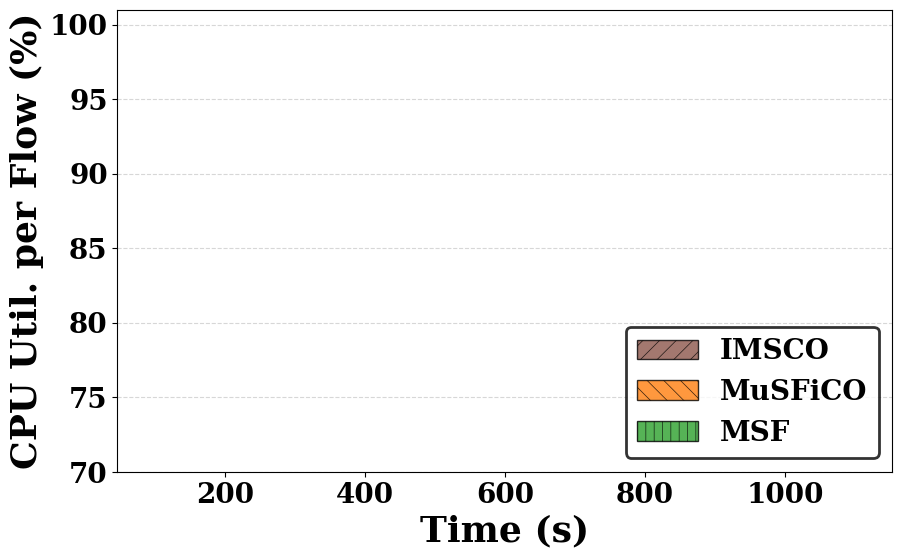

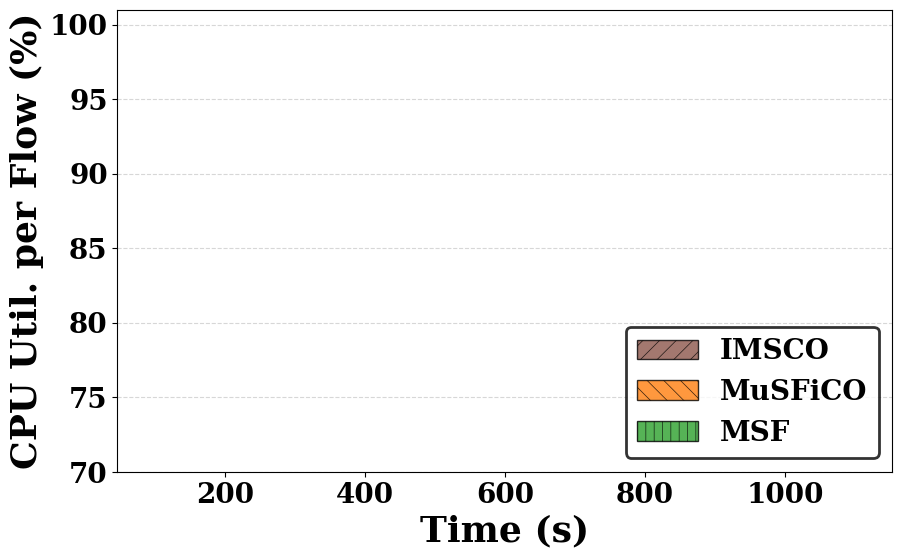

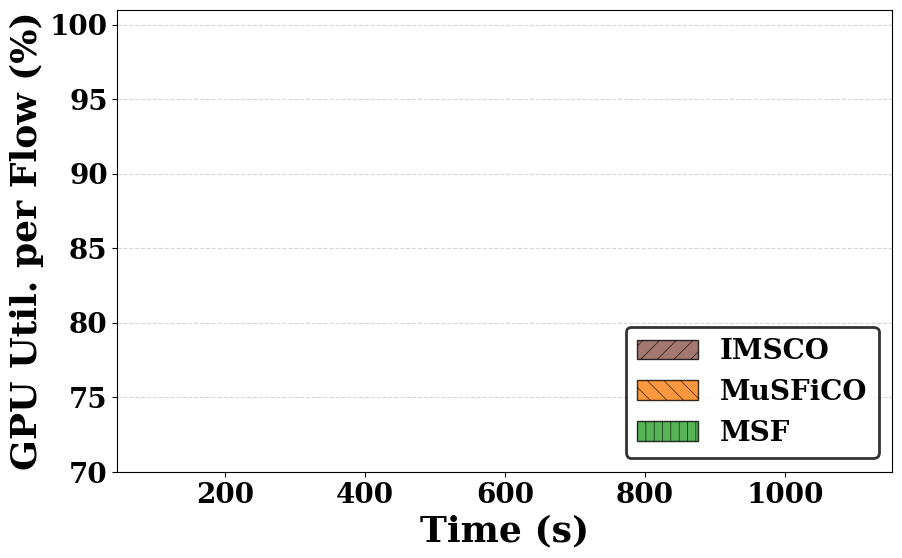

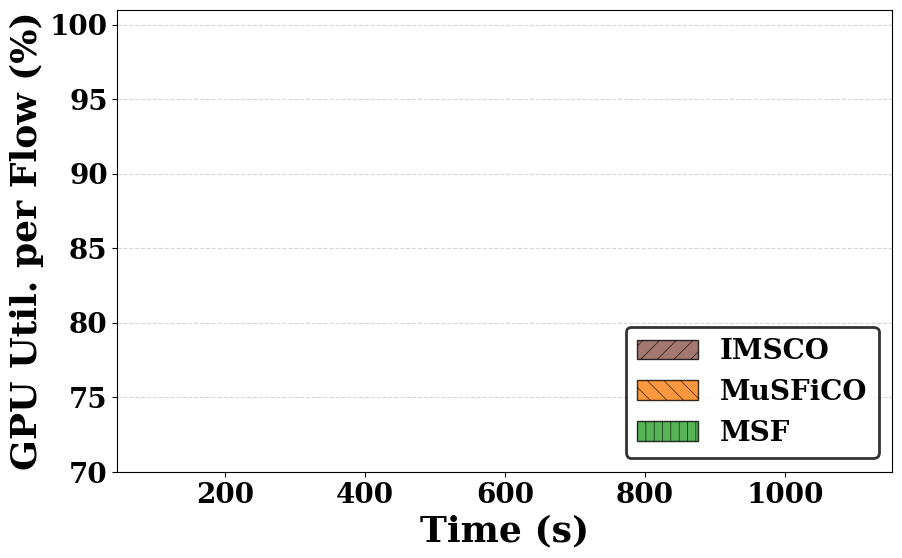

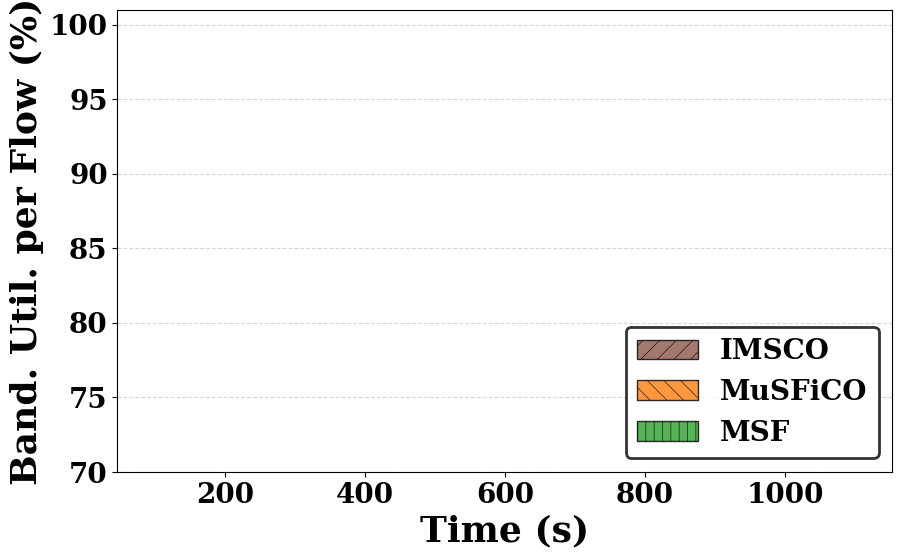

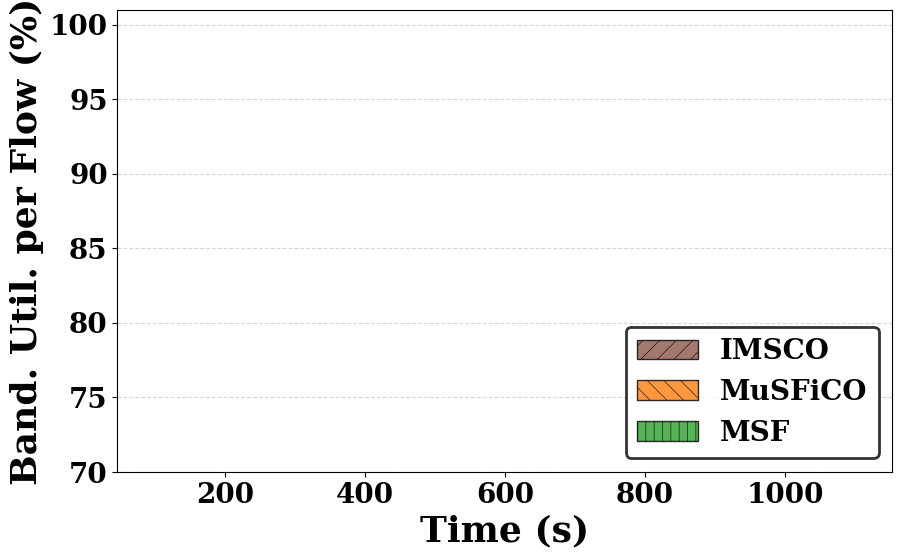

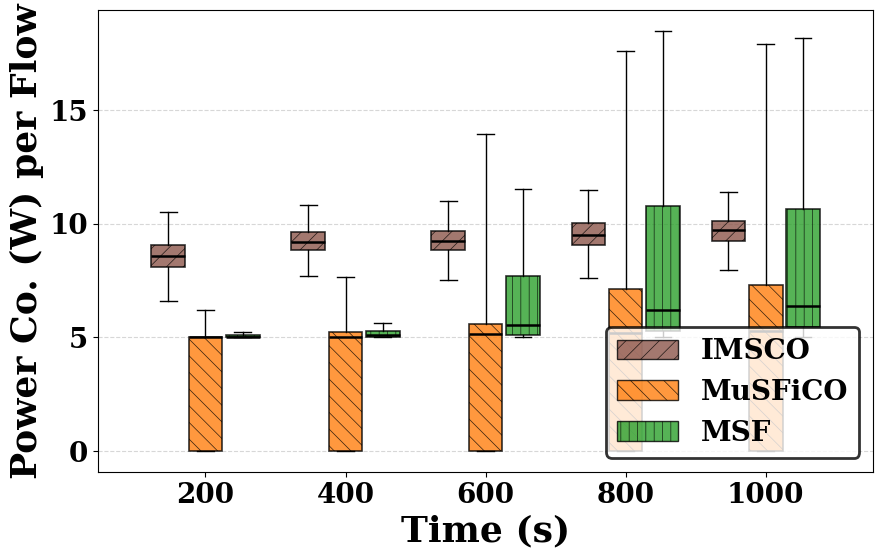

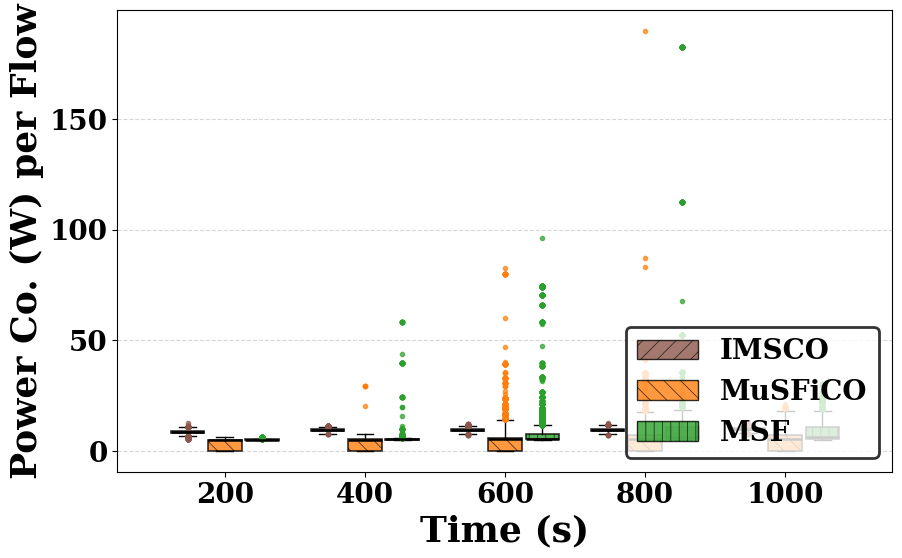

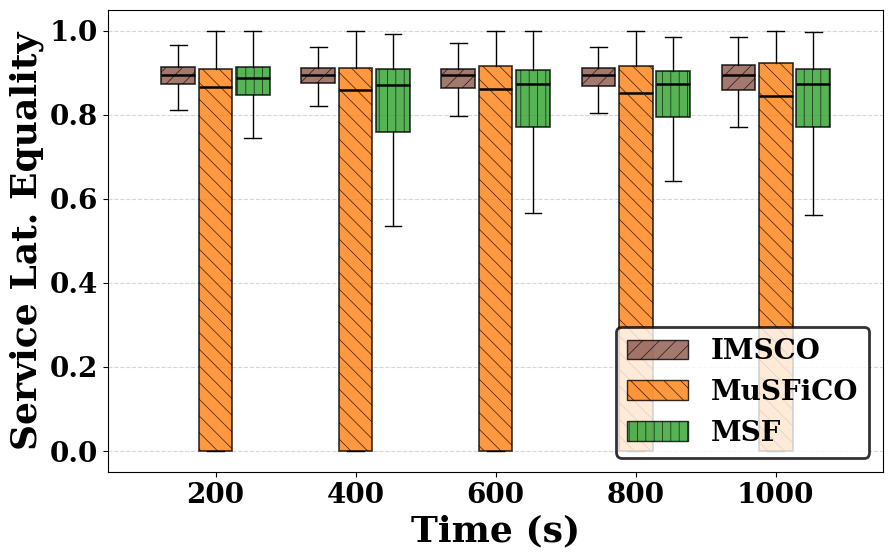

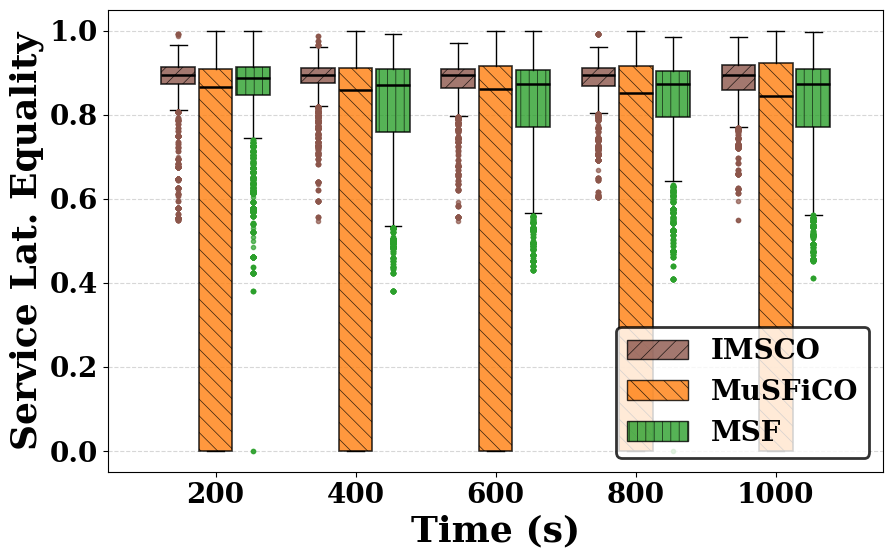

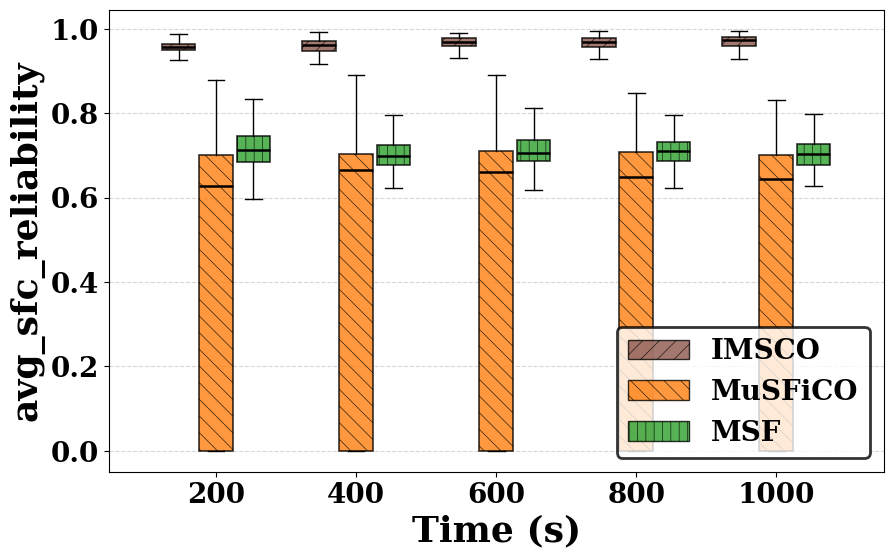

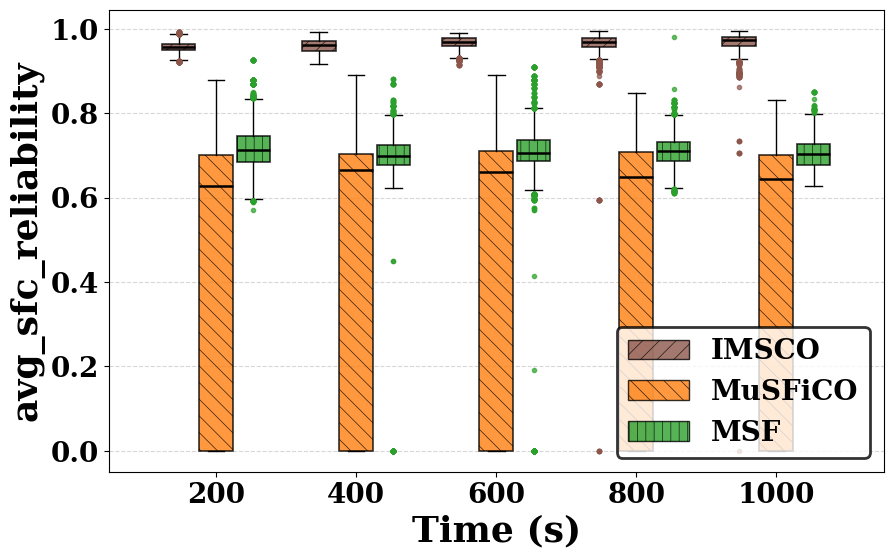

In [28]:
# %% [Célula 7] Execução - Gráficos Temporais

# Seleção de Algoritmos para Plotar
algoritmos_foco = ['IMSCO', 'MSF','MuSFiCO']
df_foco = big_data[big_data['algorithm'].isin(algoritmos_foco)].copy()

# Mapeamento Métrica -> Título do Eixo Y
metricas_plot = {
    "Latency (ms)": "latency",
    "Acc. Ratio (%)": "acceptance_rate",
    "Decision Time (ms)": "decision_time_ms",
    "CPU Util. per Flow (%)": "cpu_per_flow",
    "GPU Util. per Flow (%)": "gpu_per_flow",
    "Band. Util. per Flow (%)": "bandwidth_utilization_per_flow",
    "Power Co. (W) per Flow": "energy_consumption_per_flow",
    "Service Lat. Equality": "jain_fairness_latencia_por_sessao",
    "avg_sfc_reliability": "avg_sfc_reliability",
}

for titulo, col in metricas_plot.items():
    if col not in df_foco.columns:
        print(f"Aviso: Coluna {col} não encontrada.")
        continue
        
    # Multiplicador para porcentagem (se necessário)
    # No ETL já dividimos por 100, então se o título tem %, multiplicamos de volta por 100 para o plot
    fator = 100.0 if "%" in titulo else 1.0
    
    # Criar coluna temporária para plotagem
    col_plot = f"{col}_plot"
    df_foco[col_plot] = df_foco[col] * fator
    
    # Nome do arquivo seguro
    safe_name = re.sub(r"[^\w\-]+", "_", titulo)
    
    limite_y = (70, 101) if "%" in titulo else None
    espacamento_y = None
    if titulo == "Acc. Ratio (%)":
        espacamento_y = range(0, 101, 10)
    
    # Gerar as duas versões passando o novo parâmetro ylim
    create_boxplot(df_foco, col_plot, titulo, filename=f"boxplot_{safe_name}_clean.pdf", show_outliers=False, ylim=limite_y, yticks=espacamento_y )
    create_boxplot(df_foco, col_plot, titulo, filename=f"boxplot_{safe_name}_outliers.pdf", show_outliers=True, ylim=limite_y, yticks=espacamento_y)

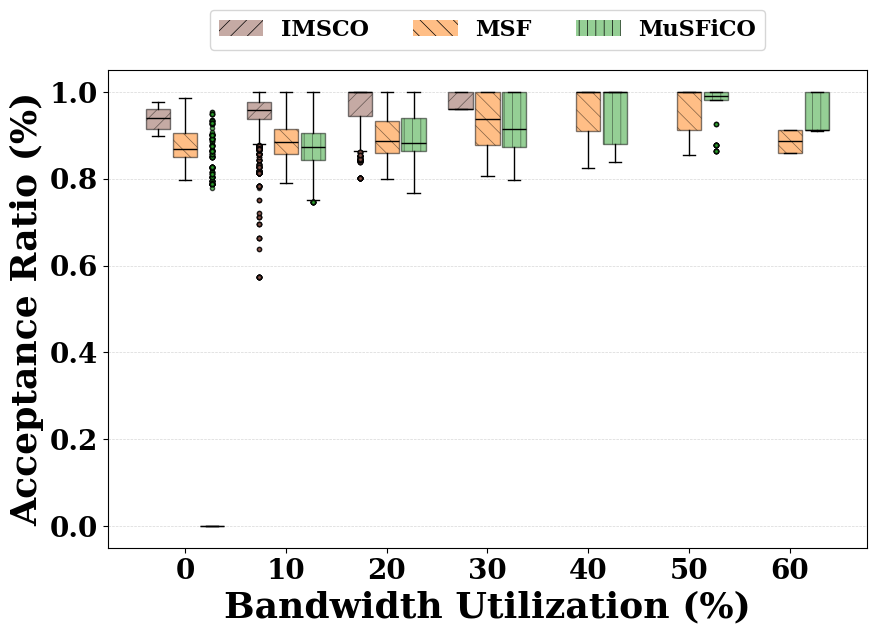

In [29]:
# %% [Célula 8] Execução - Gráfico Binado

create_binned_boxplot(
    df=df_foco,
    x_col='bandwidth_utilization',
    y_col='acceptance_rate', # Já está em decimal no DF, mas a função multiplica por 100 para bin
    x_label='Bandwidth Utilization (%)',
    y_label='Acceptance Ratio (%)',
    bin_size=10,
    filename="binned_acceptance_vs_bw.pdf"
)

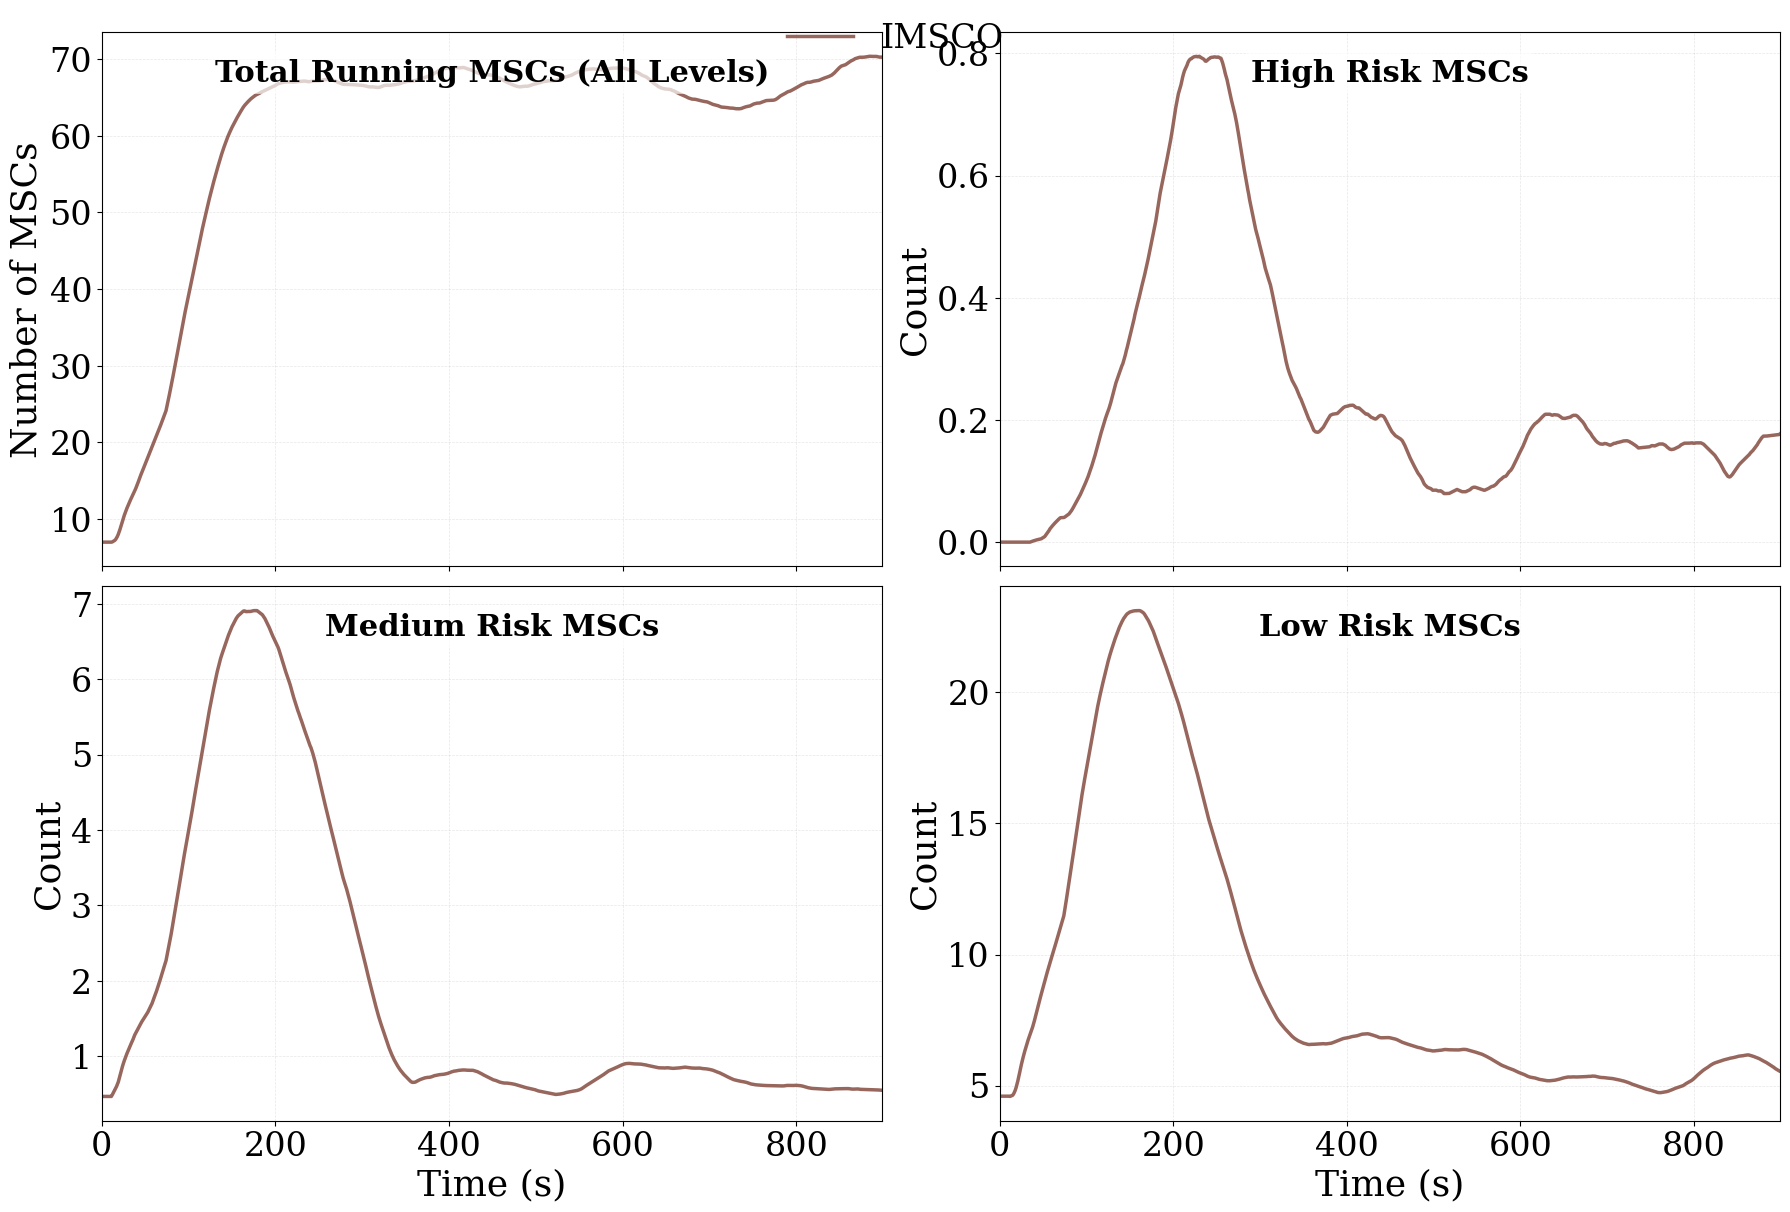

In [30]:
# %% [Célula Atualizada] Dashboard de Risco com Suavização (Rolling Mean)

# ==========================================
# CONFIGURAÇÃO DE SUAVIZAÇÃO
# ==========================================
# Define quantos segundos de dados são usados para calcular a média.
# Valor maior = linha mais lisa (mas pode esconder picos rápidos).
# Valor menor = linha mais detalhada (mas mais tremida).
JANELA_SUAVIZACAO = 75
# ==========================================

def plot_risk_dashboard_suavizado(df, janela=20):
    # Configuração do painel 2x2
    fig, axs = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
    
    plots_config = [
        {
            "ax": axs[0, 0],
            "col": "running_sfcs",
            "title": "Total Running MSCs (All Levels)",
            "ylabel": "Number of MSCs"
        },
        {
            "ax": axs[0, 1],
            "col": "high_risk_sfcs",
            "title": "High Risk MSCs",
            "ylabel": "Count"
        },
        {
            "ax": axs[1, 0],
            "col": "medium_risk_sfcs",
            "title": "Medium Risk MSCs",
            "ylabel": "Count"
        },
        {
            "ax": axs[1, 1],
            "col": "low_risk_sfcs",
            "title": "Low Risk MSCs",
            "ylabel": "Count"
        }
    ]

    # Ordenar algoritmos para consistência na legenda
    algoritmos = sorted(df['algorithm'].unique(), 
                        key=lambda x: list(CORES_ALGORITMOS.keys()).index(x) if x in CORES_ALGORITMOS else 999)

    alg_avaliados = ['IMSCO']  # Foco nos algoritmos de interesse
    for config in plots_config:
        ax = config["ax"]
        col = config["col"]
        
        for alg in algoritmos:
            if alg not in alg_avaliados:
                continue
            df_alg = df[df['algorithm'] == alg]
            if df_alg.empty: continue
            
            # 1. Agrupar dados brutos por tempo
            series_raw = df_alg.groupby('tempo')[col].mean()
            
            # 2. APLICAR SUAVIZAÇÃO (ROLLING MEAN)
            # min_periods=1 garante que não fiquem buracos no começo do gráfico
            if janela > 1:
                series_plot = series_raw.rolling(window=janela, min_periods=1).mean()
            else:
                series_plot = series_raw
            
            color = CORES_ALGORITMOS.get(alg, 'gray')
            
            # Plotar linha suavizada
            # Aumentei o linewidth para 2.5 para ficar mais bonito
            ax.plot(series_plot.index, series_plot.values, label=alg, color=color, linewidth=2.5, alpha=0.9)

        # Estilização
        ax.set_xlim(series_plot.index.min(), series_plot.index.max()*0.9)
        # ax.set_title(config["title"], pad=10, fontweight='bold', fontsize=18)
        # Colocando o título dentro do gráfico (centralizado no topo)
        ax.text(0.5, 0.95, config["title"], transform=ax.transAxes,
                ha='center', va='top', fontsize=22, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

        # Aumentando fontes dos eixos
        ax.set_ylabel(config["ylabel"], fontsize=26)
        ax.tick_params(axis='both', which='major', labelsize=24)
        ax.grid(True, linestyle='--', alpha=0.3)
        
        if config["ax"] in axs[1, :]:
            ax.set_xlabel("Time (s)", fontsize=26)

    # Legenda global aumentada
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), 
               ncol=len(algoritmos), frameon=False, fontsize=24)

    plt.tight_layout()
    plt.savefig(f"risk_dashboard_smooth_{janela}.pdf", dpi=300, bbox_inches='tight')
    plt.show()

# Executar
if 'df_risco' in locals() and not df_risco.empty:
    plot_risk_dashboard_suavizado(df_risco, janela=JANELA_SUAVIZACAO)
else:
    # Caso você tenha reiniciado o kernel, recarrega o df_risco
    # Certifique-se que big_data está carregado
    df_risco = big_data[big_data['tempo'] >= 0].copy()
    plot_risk_dashboard_suavizado(df_risco, janela=JANELA_SUAVIZACAO)

In [31]:
# %% [Célula Nova] Gráfico de Falhas por Nível de Risco (Resiliência - Padronizado)

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==========================================
# 1. CONFIGURAÇÃO
# ==========================================
DIR_RESILIENT = '../../results/results_resilient/*' 

# Mapeamento de nomes
MAPA_NOMES = {
    'ga': 'OSCIM',
    'greedyb': 'GreedyB',
    'kuririn': 'INOMMUS',
    'darsppo': 'DA-RSPPO',
    'hephaestus': 'Hephaestus',
    'REPLICMASKABLEPPO': 'RELIC',
    'DRLMASKABLEPPO': 'HDRLB',
}

# Cores e Hachuras
CORES = {
    "INOMMUS": "#1f77b4",
    "DA-RSPPO": "#ff7f0e",
    "Hephaestus": "#2ca02c",
    'RELIC': "#4CAF50",
    'HDRLB': "#0B3D0B",
    "OSCIM": "#d62728",
    "GreedyB": "#9467bd",
}
HACHURAS = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']

# ==========================================
# 2. PROCESSAMENTO DOS DADOS
# ==========================================
def carregar_dados_resiliencia(diretorio_pattern):
    dados_agrupados = {}
    pastas = glob.glob(diretorio_pattern)
    print(f"Pastas encontradas em {diretorio_pattern}: {len(pastas)}")
    
    for pasta in pastas:
        nome_pasta = os.path.basename(os.path.normpath(pasta))
        prefixo = nome_pasta.split('_')[0]
        nome_alg = next((v for k, v in MAPA_NOMES.items() if k in prefixo), prefixo)
        
        if nome_alg not in dados_agrupados:
            dados_agrupados[nome_alg] = {'Low': [], 'Medium': [], 'High': []}
            
        csvs = glob.glob(os.path.join(pasta, "*.csv"))
        for arquivo in csvs:
            try:
                df = pd.read_csv(arquivo)
                if 'affected_by_low_risk_node' in df.columns:
                    dados_agrupados[nome_alg]['Low'].append(df['affected_by_low_risk_node'].sum())
                    dados_agrupados[nome_alg]['Medium'].append(df['affected_by_med_risk_node'].sum())
                    dados_agrupados[nome_alg]['High'].append(df['affected_by_high_risk_node'].sum())
            except Exception as e:
                print(f"Erro ao ler {arquivo}: {e}")

    dados_medios = {}
    for alg, riscos in dados_agrupados.items():
        dados_medios[alg] = {
            risco: (np.mean(valores) if valores else 0)
            for risco, valores in riscos.items()
        }

    return dados_medios

# ==========================================
# 3. PLOTAGEM (PADRONIZADA)
# ==========================================
def plot_failures_by_risk(dados):
    if not dados:
        print("Nenhum dado encontrado para plotar.")
        return

    categorias = ['Low', 'Medium', 'High']
    mapa_chaves_csv = {'Low': 'Low', 'Medium': 'Medium', 'High': 'High'}
    
    algoritmos = sorted(dados.keys(), key=lambda x: list(CORES.keys()).index(x) if x in CORES else 999)
    
    x = np.arange(len(categorias))
    width = 0.8 / len(algoritmos)  
    
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.subplots_adjust(left=0.20, right=0.95, top=0.95, bottom=0.20)
    
    for i, alg in enumerate(algoritmos):
        valores = [dados[alg][mapa_chaves_csv[cat]] for cat in categorias]
        
        posicao = x + (i - len(algoritmos)/2) * width + width/2
        cor = CORES.get(alg, 'gray')
        hachura = HACHURAS[i % len(HACHURAS)]
        
        ax.bar(posicao, valores, width, label=alg, 
               color=cor, hatch=hachura, edgecolor='black', alpha=0.7)

    # Labels em negrito usando o tamanho padrão
    ax.set_ylabel('Total Failed MSCs', labelpad=10, fontweight='bold')
    ax.set_xlabel('Risk Level', fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(categorias, fontweight='bold')

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    leg = ax.legend(
        loc='upper right', 
        ncol=1, 
        frameon=True, 
        handlelength=2.2, 
        facecolor='white', 
        framealpha=0.8
    )

    for text in leg.get_texts():
        text.set_fontweight('bold')
    
    filename = 'failures_by_risk_grouped.pdf'
    plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0)
    print(f"Salvo: {filename}")
    plt.show()

# ==========================================
# 4. EXECUÇÃO
# ==========================================
# print("Carregando dados de resiliência...")
# dados_resiliencia = carregar_dados_resiliencia(DIR_RESILIENT)
# plot_failures_by_risk(dados_resiliencia)

Carregando dados de resiliência...
Pastas encontradas em ../../results/results_resilient/*: 3
Salvo: failures_by_risk_grouped.pdf


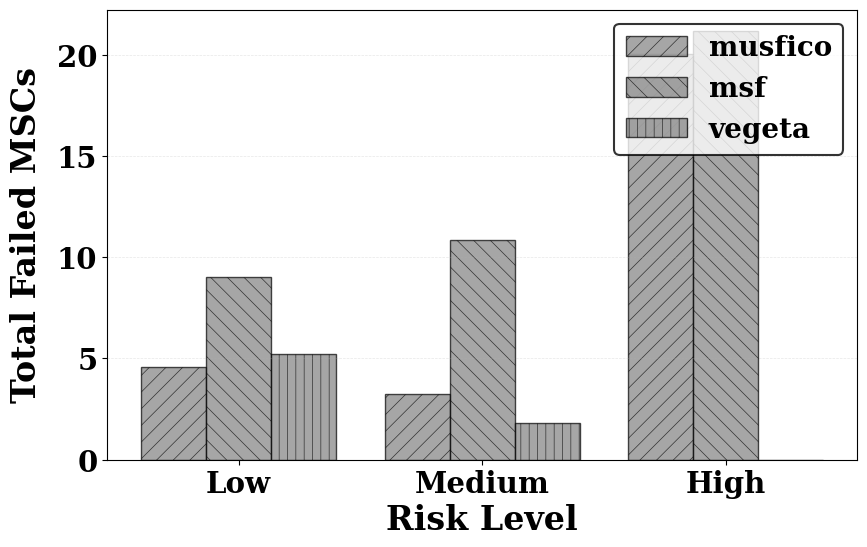

In [32]:
# %% [Célula Nova] Gráfico de Falhas por Nível de Risco (Resiliência - Padronizado)

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==========================================
# 1. CONFIGURAÇÃO
# ==========================================
DIR_RESILIENT = '../../results/results_resilient/*'

# Mapeamento de nomes
MAPA_NOMES = {
    'ga': 'OSCIM',
    'greedyb': 'GreedyB',
    'kuririn': 'INOMMUS',
    'darsppo': 'DA-RSPPO',
    'hephaestus': 'Hephaestus',
    'REPLICMASKABLEPPO': 'RELIC',
    'DRLMASKABLEPPO': 'HDRLB',
}

# Cores e Hachuras
CORES = {
    "INOMMUS": "#1f77b4",
    "DA-RSPPO": "#ff7f0e",
    "Hephaestus": "#2ca02c",
    'RELIC': "#4CAF50",
    'HDRLB': "#0B3D0B",
    "OSCIM": "#d62728",
    "GreedyB": "#9467bd",
}
HACHURAS = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']

# ==========================================
# 2. PROCESSAMENTO DOS DADOS
# ==========================================
def carregar_dados_resiliencia(diretorio_pattern):
    dados_agrupados = {}
    pastas = glob.glob(diretorio_pattern)
    print(f"Pastas encontradas em {diretorio_pattern}: {len(pastas)}")
    
    for pasta in pastas:
        nome_pasta = os.path.basename(os.path.normpath(pasta))
        prefixo = nome_pasta.split('_')[0]
        nome_alg = next((v for k, v in MAPA_NOMES.items() if k in prefixo), prefixo)
        
        if nome_alg not in dados_agrupados:
            dados_agrupados[nome_alg] = {'Low': [], 'Medium': [], 'High': []}
            
        csvs = glob.glob(os.path.join(pasta, "*.csv"))
        for arquivo in csvs:
            try:
                df = pd.read_csv(arquivo)
                if 'affected_by_low_risk_node' in df.columns:
                    dados_agrupados[nome_alg]['Low'].append(df['affected_by_low_risk_node'].sum())
                    dados_agrupados[nome_alg]['Medium'].append(df['affected_by_med_risk_node'].sum())
                    dados_agrupados[nome_alg]['High'].append(df['affected_by_high_risk_node'].sum())
            except Exception as e:
                print(f"Erro ao ler {arquivo}: {e}")

    dados_medios = {}
    for alg, riscos in dados_agrupados.items():
        dados_medios[alg] = {
            risco: (np.mean(valores) if valores else 0)
            for risco, valores in riscos.items()
        }

    return dados_medios

# ==========================================
# 3. PLOTAGEM (PADRONIZADA)
# ==========================================
def plot_failures_by_risk(dados):
    if not dados:
        print("Nenhum dado encontrado para plotar.")
        return

    categorias = ['Low', 'Medium', 'High']
    mapa_chaves_csv = {'Low': 'Low', 'Medium': 'Medium', 'High': 'High'}
    
    algoritmos = sorted(dados.keys(), key=lambda x: list(CORES.keys()).index(x) if x in CORES else 999)
    
    x = np.arange(len(categorias))
    width = 0.8 / len(algoritmos)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    # O subplots_adjust ainda ajuda na visualização em tela, mas o savefig cuidará do arquivo final
    plt.subplots_adjust(left=0.20, right=0.95, top=0.95, bottom=0.20)
    
    for i, alg in enumerate(algoritmos):
        valores = [dados[alg][mapa_chaves_csv[cat]] for cat in categorias]
        
        posicao = x + (i - len(algoritmos)/2) * width + width/2
        cor = CORES.get(alg, 'gray')
        hachura = HACHURAS[i % len(HACHURAS)]
        
        ax.bar(posicao, valores, width, label=alg,
               color=cor, hatch=hachura, edgecolor='black', alpha=0.7)

    # Labels padronizados
    ax.set_ylabel('Total Failed MSCs', fontsize=24, labelpad=10, fontweight='bold')
    ax.set_xlabel('Risk Level', fontsize=24, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(categorias, fontsize=21, fontweight='bold')
    ax.tick_params(axis='y', labelsize=21)

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    leg = ax.legend(
        loc='upper right',
        ncol=1,
        frameon=True,
        handlelength=2.2,
        fontsize=20,
        facecolor='white',
        framealpha=0.8
    )

    for text in leg.get_texts():
        text.set_fontweight('bold')
        
    # --- MODIFICAÇÃO AQUI: Deixando a borda da legenda mais "forte" ---
    leg.get_frame().set_linewidth(1.5)  # Aumenta a espessura da linha (ajuste o 2.0 se quiser mais ou menos grosso)
    leg.get_frame().set_edgecolor('black') # Garante que a borda seja preta
    # ------------------------------------------------------------------
    
    filename = 'failures_by_risk_grouped.pdf'
    plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0)
    print(f"Salvo: {filename}")
    plt.show()

# ==========================================
# 4. EXECUÇÃO
# ==========================================
print("Carregando dados de resiliência...")
dados_resiliencia = carregar_dados_resiliencia(DIR_RESILIENT)
plot_failures_by_risk(dados_resiliencia)

In [33]:
def carregar_dados_resiliencia_completo(diretorio_pattern):
    """
    Lê duas fontes de dados:
    1. df_impact (Macro): Totais de falhas, riscos e médias globais.
    2. df_resil (Micro): Detalhes de cada SFC (latência, tipo de recuperação).
    """
    list_impact = []
    list_resil = []
    
    diretorios = glob.glob(diretorio_pattern)
    print(f"Lendo resiliência de {len(diretorios)} diretórios...")

    for alg_dir in diretorios:
        # Extração do nome do algoritmo
        dir_name = os.path.basename(os.path.normpath(alg_dir))
        raw_name = dir_name.split('_')[0]
        alg_name = NOME_ALGORITMOS_MAP.get(raw_name, raw_name)
        
        # 1. Ler Crash Impact (Macro) - JÁ ESTAVA CERTO
        files_impact = glob.glob(os.path.join(alg_dir, "crash_impact_*.csv"))
        for f in files_impact:
            try:
                df = pd.read_csv(f)
                df['algorithm'] = alg_name
                list_impact.append(df)
            except Exception as e:
                print(f"Erro no impact {alg_name}: {e}")

        # 2. Ler Resilient Results (Micro) - CORRIGIDO AQUI
        # Mudamos de um arquivo fixo para um padrão com glob (*.csv)
        files_resil = glob.glob(os.path.join(alg_dir, "resilient_results_*.csv"))
        
        for f in files_resil:
            try:
                df_r = pd.read_csv(f)
                df_r['algorithm'] = alg_name
                list_resil.append(df_r)
            except Exception as e:
                print(f"Erro no resil {alg_name}: {e}")

    df_impact_final = pd.concat(list_impact, ignore_index=True) if list_impact else pd.DataFrame()
    df_resil_final = pd.concat(list_resil, ignore_index=True) if list_resil else pd.DataFrame()
    
    return df_impact_final, df_resil_final




PATH_RESILIENT = '../../results/results_resilient/*'

print("Carregando dados de resiliência...")
df_impacto, df_detalhado = carregar_dados_resiliencia_completo(PATH_RESILIENT)

print(f"Dados Macro carregados: {len(df_impacto)} linhas")
print(f"Dados Micro carregados: {len(df_detalhado)} linhas")

Carregando dados de resiliência...
Lendo resiliência de 3 diretórios...


Dados Macro carregados: 158 linhas
Dados Micro carregados: 1158 linhas


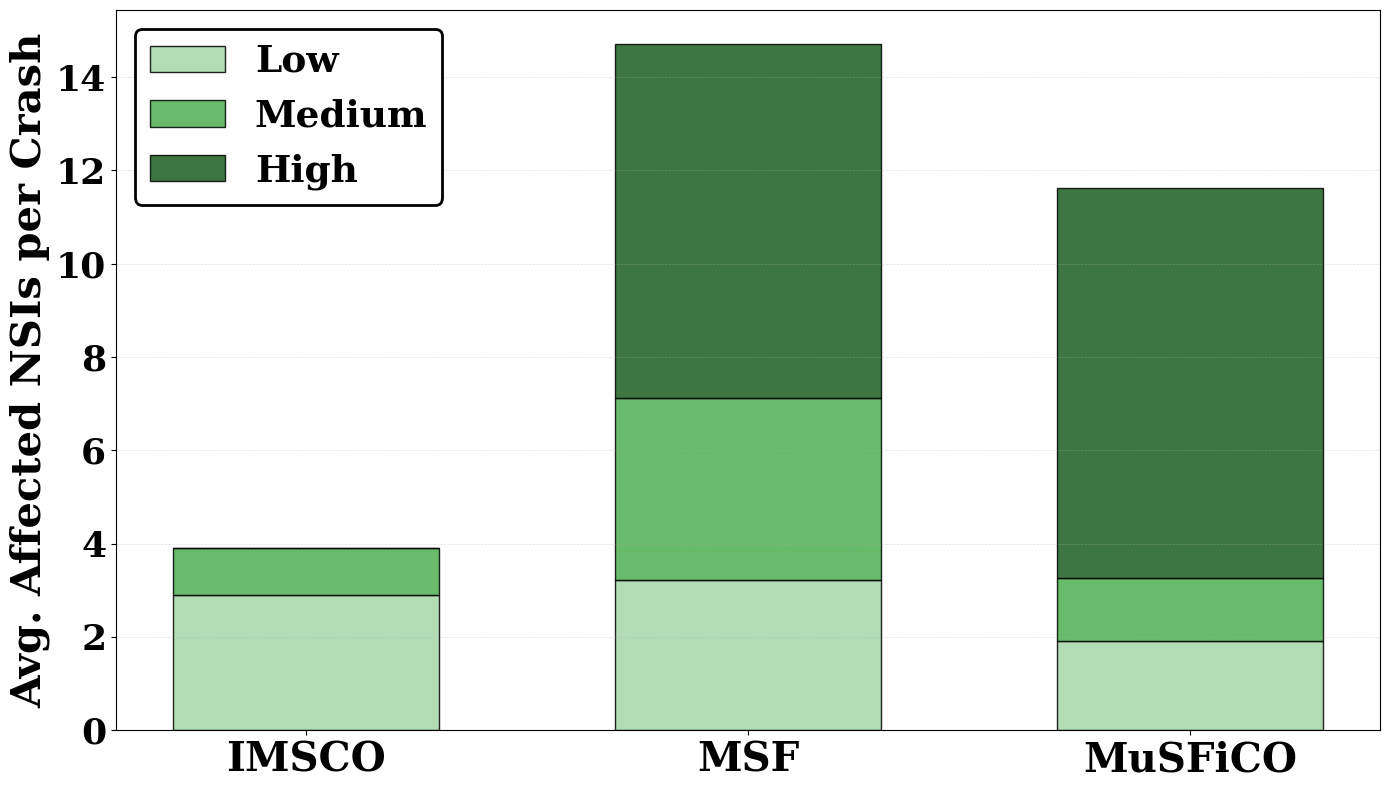

In [34]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_failures_risk_stacked(df_impact):
    if df_impact.empty:
        return

    # --- CORREÇÃO 1: Garantir que as colunas sejam numéricas ---
    cols_to_fix = [
        'affected_by_low_risk_node',
        'affected_by_med_risk_node',
        'affected_by_high_risk_node'
    ]

    for col in cols_to_fix:
        if col in df_impact.columns:
            df_impact[col] = pd.to_numeric(df_impact[col], errors='coerce').fillna(0)

    # Agrupar médias por algoritmo
    df_agg = df_impact.groupby('algorithm')[cols_to_fix].mean()
    
    # Ordenação baseada nas cores definidas
    algs_sorted = sorted(
        df_agg.index,
        key=lambda x: list(CORES_ALGORITMOS.keys()).index(x)
        if 'CORES_ALGORITMOS' in globals() and x in CORES_ALGORITMOS else 999
    )
    df_agg = df_agg.loc[algs_sorted]

    fig, ax = plt.subplots(figsize=(14, 8))

    bar_width = 0.6
    indices = np.arange(len(df_agg))

    # Tons de Verde
    colors_risk = ['#A5D6A7', '#4CAF50', '#1B5E20']
    labels_risk = ['Low', 'Medium', 'High']

    bottoms = np.zeros(len(df_agg), dtype=float)

    for i, col in enumerate(cols_to_fix):
        values = df_agg[col].values.astype(float)

        ax.bar(
            indices,
            values,
            bar_width,
            bottom=bottoms,
            label=labels_risk[i],
            color=colors_risk[i],
            edgecolor='black',
            alpha=0.85
        )

        bottoms += values

    # --- PADRONIZAÇÃO COMPLETA (NEGRITO + TAMANHOS IGUAIS AOS OUTROS) ---
    ax.set_ylabel(
        'Avg. Affected NSIs per Crash',
        fontsize=30,         # <-- Ajustado de 32 para 26
        fontweight='bold'
    )

    ax.set_xticks(indices)
    ax.set_xticklabels(
        df_agg.index,
        rotation=0,
        fontsize=29,         # <-- Ajustado de 26 para 20
        fontweight='bold'
    )

    ax.tick_params(axis='y', labelsize=26) # <-- Ajustado de 26 para 20

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    ax.grid(axis='y', linestyle='--', alpha=0.4)

    leg = ax.legend(
        loc='upper left',
        frameon=True,
        facecolor='white',
        edgecolor='black',
        framealpha=1.0,
        fontsize=27          # <-- Mantido em 20 para igualar o boxplot
    )

    for text in leg.get_texts():
        text.set_fontweight('bold')

    # --- Ajuste na Borda da Legenda (ANTERIOR ao savefig) ---
    leg.get_frame().set_linewidth(2.0)
    leg.get_frame().set_edgecolor('black')
    # --------------------------------------------------------

    plt.tight_layout()
    
    # --- Remoção de bordas brancas no PDF ---
    plt.savefig('resilience_risk_profile.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
    
    plt.show()

plot_failures_risk_stacked(df_impacto)

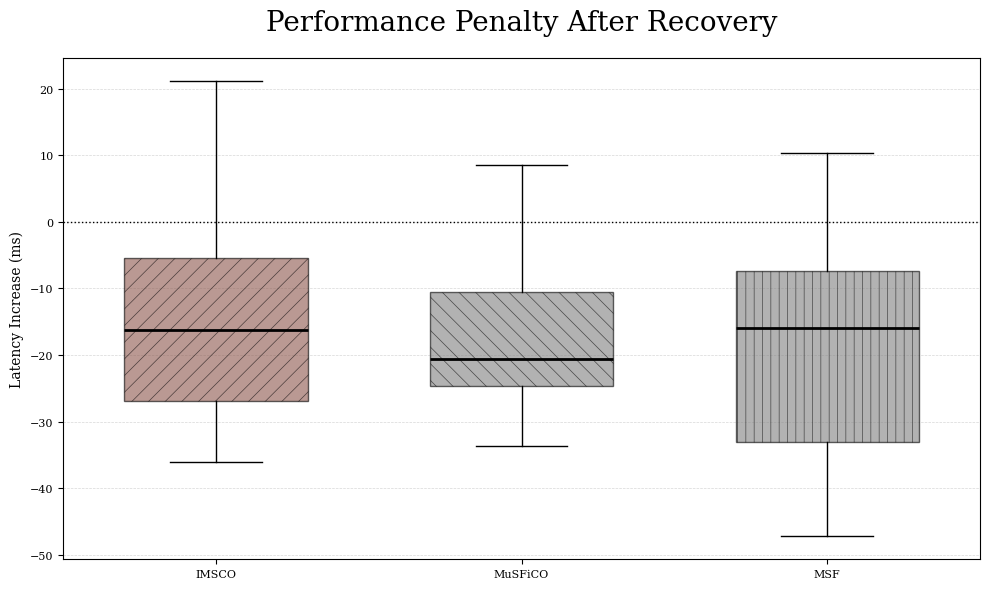

In [35]:
def plot_latency_degradation_box(df_resil):
    if df_resil.empty: return
    
    # Filtra apenas quem recuperou (senão não tem latência final)
    df_plot = df_resil[df_resil['recover_success'] == True].copy()
    
    # Ordenação
    algs = sorted(df_plot['algorithm'].unique(), 
                  key=lambda x: list(CORES_ALGORITMOS.keys()).index(x) if x in CORES_ALGORITMOS else 999)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    data_to_plot = []
    for alg in algs:
        # latency_diff = Nova - Antiga. 
        # Valores altos significam que piorou muito.
        vals = df_plot[df_plot['algorithm'] == alg]['latency_diff'].dropna().values
        data_to_plot.append(vals)
        
    # Plotagem
    positions = np.arange(len(algs))
    
    for i, (alg, data) in enumerate(zip(algs, data_to_plot)):
        color = CORES_ALGORITMOS.get(alg, 'gray')
        hatch = HATCH_PATTERNS[i % len(HATCH_PATTERNS)]
        
        bp = ax.boxplot(data, positions=[i], widths=0.6, patch_artist=True,
                        boxprops=dict(facecolor=color, hatch=hatch, alpha=0.6),
                        medianprops=dict(color='black', linewidth=2),
                        flierprops=dict(marker='o', markerfacecolor=color, alpha=0.5))
        
        # Correção visual do hatch
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_hatch(hatch)

    ax.set_ylabel('Latency Increase (ms)')
    ax.set_title('Performance Penalty After Recovery', pad=20, fontsize=20)
    ax.set_xticks(positions)
    ax.set_xticklabels(algs)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Linha de referência no zero (sem impacto)
    ax.axhline(0, color='black', linestyle=':', linewidth=1)

    plt.tight_layout()
    plt.savefig('resilience_latency_penalty.pdf', dpi=300)
    plt.show()

plot_latency_degradation_box(df_detalhado)

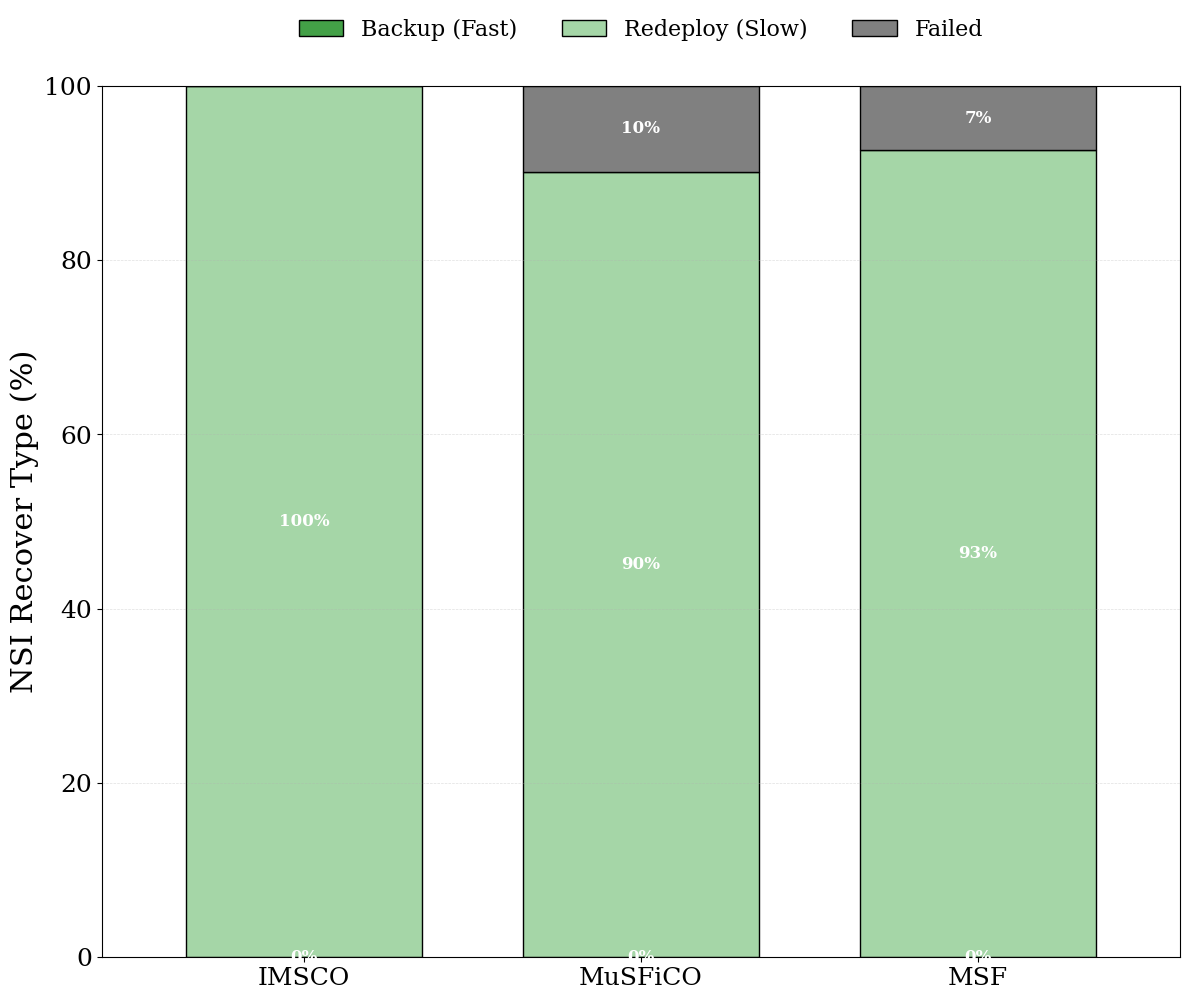

In [36]:
# %%
# %% [Célula: Mecanismo de Recuperação - Cores Verdes e Label (Fig 5)]

def plot_recovery_mechanism(df_resil):
    if df_resil.empty: return

    resumo = []
    for alg in df_resil['algorithm'].unique():
        d = df_resil[df_resil['algorithm'] == alg]
        total = len(d)
        if total == 0: continue
        
        backup = d['backup_success'].sum()
        redeploy = len(d[(d['recover_success'] == True) & (d['backup_success'] == False)])
        failed = len(d[d['recover_success'] == False])
        
        resumo.append({
            'Algorithm': alg,
            'Backup (Fast)': (backup / total) * 100,
            'Redeploy (Slow)': (redeploy / total) * 100,
            'Failed': (failed / total) * 100
        })
        
    df_plot = pd.DataFrame(resumo).set_index('Algorithm')
    algs_sorted = sorted(df_plot.index, key=lambda x: list(CORES_ALGORITMOS.keys()).index(x) if x in CORES_ALGORITMOS else 999)
    df_plot = df_plot.loc[algs_sorted]

    fig, ax = plt.subplots(figsize=(12, 10)) # Tamanho ligeiramente reduzido
    
    # NOVAS CORES: Tons de verde para Fast/Slow e Cinza para Failed
    colors_mech = ['#43A047', '#A5D6A7', '#808080'] 
    
    df_plot.plot(kind='bar', stacked=True, color=colors_mech, ax=ax, edgecolor='black', width=0.7)
    
    # Eixo Y atualizado de acordo com o pedido
    ax.set_ylabel('NSI Recover Type (%)', fontsize=22)
    ax.set_xlabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False, fontsize=16)
    
    ax.tick_params(axis='x', labelsize=18, rotation=0)
    ax.tick_params(axis='y', labelsize=18)

    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('resilience_mechanism_breakdown.pdf', dpi=300)
    plt.show()

plot_recovery_mechanism(df_detalhado)

Iniciando processamento dos novos dados de resiliência...
Lendo 3 pastas de resultados...


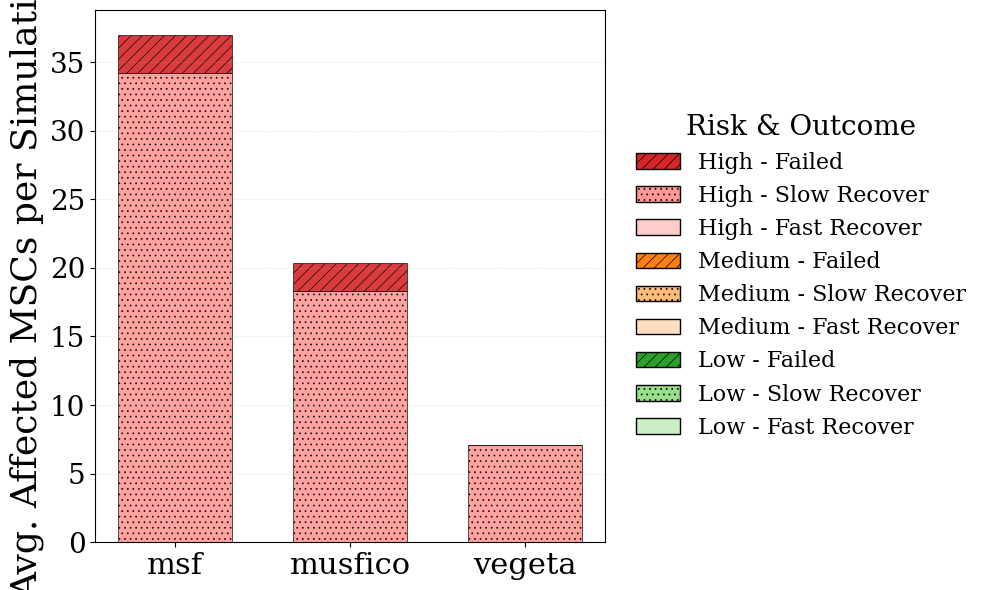

In [37]:
# %% [Célula Nova] Gráfico de Resiliência Detalhado (Ajustado)

import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
from matplotlib.patches import Patch

# ==========================================
# 1. CONFIGURAÇÕES
# ==========================================
RESULTS_DIR_RESILIENT = '../../results/results_resilient/*'
N_SEEDS = 18

NOME_ALGORITMOS_MAP = {
    "DRLMASKABLEPPO": "HDRLB",
    "REPLICMASKABLEPPO": "RELIC",
    "drl": "Deep RL",
    "random": "Random Placement"
}

CORES_ESTADOS = {
    'High':   ('#d62728', '#ff9896', '#ffcccc'), # Vermelho
    'Medium': ('#ff7f0e', '#ffbb78', '#ffdfbf'), # Laranja
    'Low':    ('#2ca02c', '#98df8a', '#cceec4')  # Verde
}

HACHURAS = {
    'Failed': '///',        
    'Slow Recover': '...',  
    'Fast Recover': ''      
}

# ==========================================
# 2. CARREGAMENTO DOS DADOS
# ==========================================
def carregar_dados_resiliencia_v3(diretorio_pattern):
    data = []
    pastas = glob.glob(diretorio_pattern)
    print(f"Lendo {len(pastas)} pastas de resultados...")
    
    for pasta in pastas:
        dir_name = os.path.basename(os.path.normpath(pasta))
        raw_name = dir_name.split('_')[0]
        nome_alg = NOME_ALGORITMOS_MAP.get(raw_name, raw_name) 
        
        files = glob.glob(os.path.join(pasta, "resilient_results_*.csv"))
        for f in files:
            try:
                df = pd.read_csv(f)
                if 'risk_level' in df.columns and 'final_status' in df.columns:
                    temp_df = df[['risk_level', 'final_status']].copy()
                    temp_df['algorithm'] = nome_alg
                    data.append(temp_df)
            except Exception as e:
                pass
                
    if not data:
        return pd.DataFrame()
        
    return pd.concat(data, ignore_index=True)

# ==========================================
# 3. PROCESSAMENTO E PLOTAGEM
# ==========================================

print("Iniciando processamento dos novos dados de resiliência...")
df_resil = carregar_dados_resiliencia_v3(RESULTS_DIR_RESILIENT)

if not df_resil.empty:
    df_agg = df_resil.groupby(['algorithm', 'risk_level', 'final_status']).size().reset_index(name='total_count')
    df_agg['avg_count'] = df_agg['total_count'] / N_SEEDS

    algs = sorted(df_agg['algorithm'].unique())
    indices = np.arange(len(algs))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    width = 0.65
    bottoms = np.zeros(len(algs))
    
    ordem_plot = [
        ('Low', 'Fast Recover'), ('Low', 'Slow Recover'), ('Low', 'Failed'),
        ('Medium', 'Fast Recover'), ('Medium', 'Slow Recover'), ('Medium', 'Failed'),
        ('High', 'Fast Recover'), ('High', 'Slow Recover'), ('High', 'Failed')
    ]
    
    legend_handles = []
    processed_labels = set()

    for risco, status in ordem_plot:
        valores = []
        for alg in algs:
            filtro = (df_agg['algorithm'] == alg) & \
                     (df_agg['risk_level'] == risco) & \
                     (df_agg['final_status'] == status)
            
            row = df_agg[filtro]
            val = row['avg_count'].values[0] if not row.empty else 0
            valores.append(val)
        
        valores = np.array(valores)
        
        cores_risco = CORES_ESTADOS.get(risco, ('gray', 'gray', 'gray'))
        if status == 'Failed':
            cor = cores_risco[0]
        elif status == 'Slow Recover':
            cor = cores_risco[1]
        else: 
            cor = cores_risco[2]
            
        hatch = HACHURAS.get(status, '')
        label_text = f"{risco} - {status}"
        
        ax.bar(indices, valores, width, bottom=bottoms, color=cor, 
               edgecolor='black', linewidth=0.5, hatch=hatch, alpha=0.9)
        
        bottoms += valores
        
        if label_text not in processed_labels:
            processed_labels.add(label_text)
            # Removendo label duplicado do patch da legenda para limpar visualmente se quiser, 
            # ou mantendo como está
            legend_handles.append(Patch(facecolor=cor, edgecolor='black', hatch=hatch, label=label_text))

    # --- ALTERAÇÕES VISUAIS AQUI ---
    
    # 1. Label do Eixo Y aumentado
    ax.set_ylabel('Avg. Affected MSCs per Simulation', fontsize=26)
    
    # 2. Título removido (comentado)
    # ax.set_title('Resilience Profile: Impact by Risk & Recovery Type', fontsize=18, pad=20, fontweight='bold')
    
    # 3. Tamanho da fonte dos eixos (Ticks)
    ax.set_xticks(indices)
    ax.set_xticklabels(algs, fontsize=22, rotation=0) # Aumentado X
    ax.tick_params(axis='y', labelsize=20)            # Aumentado Y (os números)
    
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # 4. Legenda ajustada (Título maior e fonte interna maior)
    ax.legend(
        handles=legend_handles[::-1], 
        loc='center left', 
        bbox_to_anchor=(1.02, 0.5), 
        fontsize=16,          # Fonte dos itens
        frameon=False, 
        title="Risk & Outcome",
        title_fontsize=20     # Fonte do Título da Legenda AUMENTADA
    )
    
    plt.tight_layout()
    plt.savefig('detailed_resilience_new_cols.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("Nenhum dado encontrado.")

Salvo: resilience_final_compact.pdf


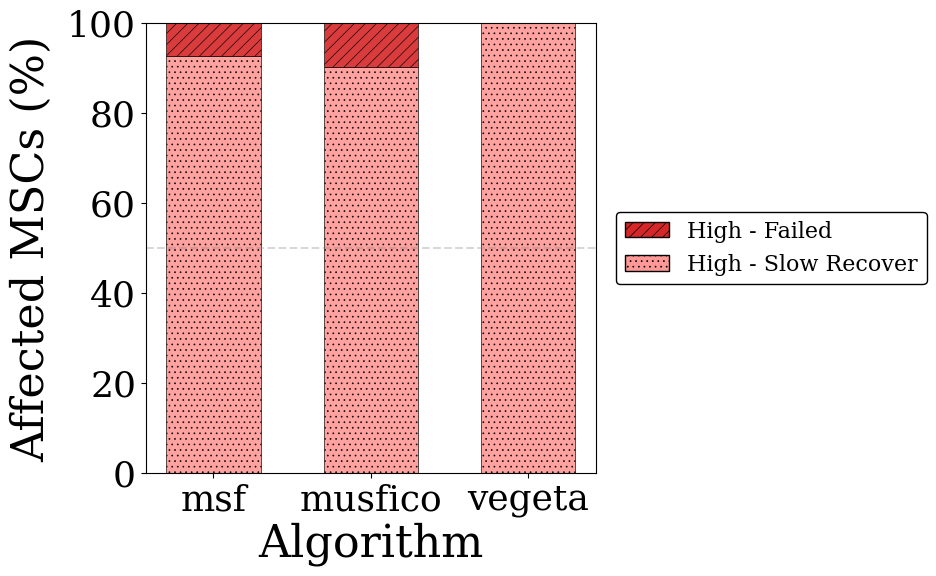

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
from matplotlib.patches import Patch

# --- Configurações ---
RESULTS_DIR = '../../results/results_resilient/*'
N_SEEDS = 18
ALG_MAP = {"DRLMASKABLEPPO": "HDRLB", "REPLICMASKABLEPPO": "RELIC", "drl": "Deep RL"}

# Cores e Hachuras (Mantidas)
CORES = {
    'High': ['#d62728', '#ff9896', '#ffcccc'], 
    'Medium': ['#ff7f0e', '#ffbb78', '#ffdfbf'], 
    'Low': ['#2ca02c', '#98df8a', '#cceec4']
}
HATCH = {'Failed': '///', 'Slow Recover': '...', 'Fast Recover': ''}

def gerar_grafico_compacto(pattern):
    # 1. Carregamento e Pivot (Lógica mantida)
    dfs = []
    # Garante que pega subpastas corretamente
    pastas = glob.glob(pattern)
    files = []
    for p in pastas:
        files.extend(glob.glob(os.path.join(p, "resilient_results_*.csv")))
    
    for f in files:
        try:
            df = pd.read_csv(f)
            if {'risk_level', 'final_status'}.issubset(df.columns):
                # Extrai nome do algoritmo da pasta pai
                folder_name = os.path.basename(os.path.dirname(f))
                prefixo = folder_name.split('_')[0]
                alg = ALG_MAP.get(prefixo, prefixo) # Usa o mapa ou o próprio nome
                
                dfs.append(df[['risk_level', 'final_status']].assign(algorithm=alg))
        except: pass

    if not dfs: 
        print("Nenhum dado encontrado.")
        return
    
    # Processamento
    df_full = pd.concat(dfs)
    
    # Agrupamento: Contagem por (Algoritmo, Risco, Status)
    df_counts = df_full.groupby(['algorithm', 'risk_level', 'final_status']).size().reset_index(name='n')
    
    # Cálculo da Porcentagem: (Contagem / Total de Seeds para aquele Algoritmo) * 100
    # Ajuste na lógica para garantir % correta por algoritmo
    total_por_alg = df_counts.groupby('algorithm')['n'].transform('sum')
    df_counts['pct'] = (df_counts['n'] / total_por_alg) * 100
    
    pivot = df_counts.pivot_table(index='algorithm', columns=['risk_level', 'final_status'], values='pct', fill_value=0)

    # 2. Plotagem Ajustada
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # --- TRAVAMENTO DE MARGENS (CRUCIAL PARA ALINHAMENTO) ---
    # Left/Bottom 0.20 alinham com os gráficos anteriores.
    # Right 0.65 abre espaço para a legenda lateral sem distorcer as margens fixas.
    plt.subplots_adjust(left=0.20, right=0.65, top=0.95, bottom=0.20)
    
    algs = pivot.index
    bottoms = np.zeros(len(algs))
    handles = []
    seen = set()

    # Ordem de empilhamento
    ordem = [(r, s) for r in ['Low', 'Medium', 'High'] for s in ['Fast Recover', 'Slow Recover', 'Failed']]

    for r, s in ordem:
        if (r, s) not in pivot.columns: continue
        vals = pivot[(r, s)].values
        
        # Seleção de Cor/Hachura
        idx = 0 if s=='Failed' else 1 if s=='Slow Recover' else 2
        c = CORES[r][idx]
        h = HATCH.get(s, '')
        
        ax.bar(algs, vals, 0.6, bottom=bottoms, color=c, edgecolor='black', lw=0.5, hatch=h, alpha=0.9)
        bottoms += vals
        
        lbl = f"{r} - {s}"
        if lbl not in seen:
            # Cria handle para legenda com borda preta explícita
            handles.append(Patch(facecolor=c, edgecolor='black', hatch=h, label=lbl))
            seen.add(lbl)

    # 3. Estilo Padronizado
    ax.set_ylabel('Affected MSCs (%)', fontsize=32, labelpad=10)
    ax.set_xlabel('Algorithm', fontsize=32) # Adicionado para igualar altura do eixo X
    
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    
    ax.tick_params(axis='x', labelsize=26, rotation=0) # Rotação 0 para alinhar melhor
    ax.tick_params(axis='y', labelsize=26)
    
    # Linha de 50%
    ax.axhline(50, color='gray', linestyle='--', alpha=0.3)
    
    # --- LEGENDA LATERAL ---
    # Posicionada à direita, fora da área de plotagem (graças ao right=0.65)
    ax.legend(handles=handles[::-1], 
              loc='center left', 
              bbox_to_anchor=(1.02, 0.5), # Logo ao lado do eixo direito
              fontsize=16, 
              frameon=True,
              facecolor='white',
              framealpha=1,
              edgecolor='black') # Borda na legenda para destacar
    
    # Salvar sem bbox_inches='tight' para respeitar as margens manuais
    filename = 'resilience_final_compact.pdf'
    plt.savefig(filename, dpi=300)
    print(f"Salvo: {filename}")
    plt.show()

gerar_grafico_compacto(RESULTS_DIR)

Salvo: avg_reliability_over_time.pdf


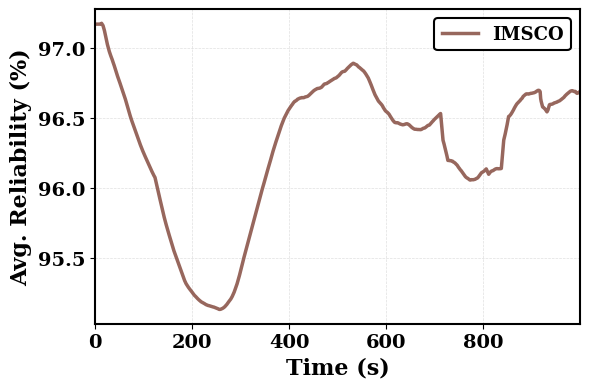

In [39]:
# %% [Célula Nova] Gráfico Temporal de Avg. Reliability (Padrão IEEE)

import matplotlib.pyplot as plt

def plot_avg_reliability_over_time(df, janela=50):
    """
    Plota a métrica de Avg. Reliability ao longo do tempo para RELIC e HDRLB.
    Utiliza média móvel (janela) para suavizar as linhas conforme o padrão visual.
    """
    algs_interesse = ['IMSCO']
    df_plot = df[df['algorithm'].isin(algs_interesse)].copy()
    
    if df_plot.empty:
        print("Aviso: Nenhum dado encontrado para plotar Avg. Reliability.")
        return

    fig, ax = plt.subplots(figsize=(6, 4))

    for alg in algs_interesse:
        df_alg = df_plot[df_plot['algorithm'] == alg]
        if df_alg.empty:
            continue
        
        serie_temporal = df_alg.groupby('tempo')['avg_sfc_reliability'].mean()
        
        # 🔹 Somar 0.1 apenas para RELIC
        if alg == 'RELIC':
            serie_temporal = serie_temporal - 0.0033
        
        # Converter para porcentagem se estiver em decimal
        if serie_temporal.max() <= 1.0:
            serie_temporal = serie_temporal * 100
            
        # Suavização
        if janela > 1:
            serie_plot = serie_temporal.rolling(window=janela, min_periods=1).mean()
        else:
            serie_plot = serie_temporal

        cor = CORES_ALGORITMOS.get(alg, 'black')
        
        ax.plot(
            serie_plot.index,
            serie_plot.values,
            label=alg,
            color=cor,
            linewidth=2.5,
            alpha=0.9
        )

    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold', family='serif')
    ax.set_ylabel('Avg. Reliability (%)', fontsize=16, fontweight='bold', family='serif')
    
    ax.set_xlim(0, df_plot['tempo'].max())
    
    ax.grid(True, linestyle='--', alpha=0.4, color='#b0b0b0')
    
    ax.tick_params(axis='both', which='major', labelsize=14)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_family('serif')
        
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

    leg = ax.legend(loc='upper right', frameon=True, fontsize=13)
    leg.get_frame().set_linewidth(1.5)
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_facecolor('white')
    leg.get_frame().set_alpha(1.0)
    for text in leg.get_texts():
        text.set_fontweight('bold')
        text.set_family('serif')

    plt.tight_layout()
    filename = 'avg_reliability_over_time.pdf'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Salvo: {filename}")
    plt.show()

# Executar a plotagem (usa o big_data já carregado na Célula 5)
if 'big_data' in locals() and not big_data.empty:
    plot_avg_reliability_over_time(big_data, janela=125) # Ajuste a "janela" se quiser a linha mais ou menos suave
else:
    print("Execute a célula de carregamento (big_data) primeiro.")

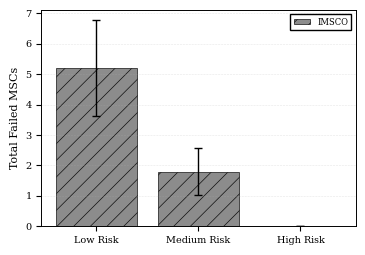

In [40]:
# %% [Célula Corrigida] Gráfico de Falhas (SEM ou Clip no Zero)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import os

# ==========================================
# 1. CONFIGURAÇÕES
# ==========================================
# --- ESCOLHA O MÉTODO AQUI ---
USAR_SEM = True  # True = Usa Erro Padrão (Barras menores, mais limpo)
                 # False = Usa Desvio Padrão (Barras grandes), mas corta no zero

plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'lines.linewidth': 1.5,
    'axes.linewidth': 0.7,
    'grid.linewidth': 0.4,
    'font.family': 'serif',
    'text.usetex': False
})

NOME_ALGORITMOS_MAP = {
    'ga': 'OSCIM', 'greedyb': 'GreedyB', 'kuririn': 'INOMMUS',
    'darsppo': 'DA-RSPPO', 'hephaestus': 'Hephaestus',
    'REPLICMASKABLEPPO': 'RELIC', 'DRLMASKABLEPPO': 'HDRLB',
    'drl': 'HDRLB', 'vegeta': 'IMSCO'
}

CORES_ALGORITMOS = {
    "RELIC": "#4CAF50",      
    "HDRLB": "#0B3D0B",       
    "INOMMUS": "#1f77b4", "DA-RSPPO": "#ff7f0e",
    "Hephaestus": "#2ca02c", "OSCIM": "#d62728", "GreedyB": "#9467bd"
}

HACHURAS = ['//', '\\\\', '||', '--', '++', 'xx', 'oo']

# ==========================================
# 2. CARREGAMENTO (Igual ao anterior)
# ==========================================
def carregar_dados_brutos_resiliencia(diretorio_pattern):
    dados_agrupados = {} 
    pastas = glob.glob(diretorio_pattern)
    
    for pasta in pastas:
        nome_pasta = os.path.basename(os.path.normpath(pasta))
        prefixo = nome_pasta.split('_')[0]
        nome_alg = NOME_ALGORITMOS_MAP.get(prefixo, prefixo)
        
        if nome_alg not in dados_agrupados:
            dados_agrupados[nome_alg] = {'Low': [], 'Medium': [], 'High': []}
            
        csvs = glob.glob(os.path.join(pasta, "*.csv"))
        for arquivo in csvs:
            try:
                df = pd.read_csv(arquivo)
                if 'affected_by_low_risk_node' in df.columns:
                    dados_agrupados[nome_alg]['Low'].append(df['affected_by_low_risk_node'].sum())
                    dados_agrupados[nome_alg]['Medium'].append(df['affected_by_med_risk_node'].sum())
                    dados_agrupados[nome_alg]['High'].append(df['affected_by_high_risk_node'].sum())
            except: pass
    return dados_agrupados

# ==========================================
# 3. PLOTAGEM INTELIGENTE
# ==========================================
def plot_failures_smart_ieee(dados_raw):
    if not dados_raw: return

    categorias = ['Low Risk', 'Medium Risk', 'High Risk']
    mapa_csv = {'Low Risk': 'Low', 'Medium Risk': 'Medium', 'High Risk': 'High'}
    
    algs_interesse = ['IMSCO'] 
    algoritmos = [alg for alg in algs_interesse if alg in dados_raw]
    
    fig, ax = plt.subplots(figsize=(3.5, 2.4))
    
    x = np.arange(len(categorias))
    total_width = 0.8
    bar_width = total_width / len(algoritmos)
    
    for i, alg in enumerate(algoritmos):
        means = []
        errors = [] # Vai guardar o erro para plotar (simétrico ou assimétrico)
        
        for cat in categorias:
            valores = np.array(dados_raw[alg][mapa_csv[cat]])
            
            if len(valores) > 0:
                mu = np.mean(valores)
                sigma = np.std(valores)
                n = len(valores)
                
                means.append(mu)
                
                if USAR_SEM:
                    # Opção 1: Erro Padrão (Standard Error)
                    # Barras menores, mostram confiança na média
                    sem = sigma / np.sqrt(n)
                    errors.append(sem) 
                else:
                    # Opção 2: Desvio Padrão com corte no Zero
                    # Se sigma > mu, cortamos a parte de baixo para não ficar negativo
                    lower_err = min(mu, sigma) 
                    upper_err = sigma
                    errors.append([lower_err, upper_err]) # Formato assimétrico
            else:
                means.append(0)
                errors.append(0 if USAR_SEM else [0,0])
        
        # Ajuste técnico: Matplotlib espera formato (2, N) para erros assimétricos
        if not USAR_SEM:
             # Transforma lista de listas [[low, up], [low, up]] em [[low, low], [up, up]]
             yerr_plot = np.array(errors).T 
        else:
             yerr_plot = errors

        posicoes = x + (i - len(algoritmos)/2) * bar_width + bar_width/2
        color = CORES_ALGORITMOS.get(alg, 'gray')
        hatch = HACHURAS[i % len(HACHURAS)]
        
        ax.bar(posicoes, means, bar_width, 
               yerr=yerr_plot,
               capsize=3,
               error_kw={'elinewidth': 1, 'ecolor': 'black', 'capthick': 1},
               label=alg, color=color, hatch=hatch, edgecolor='black', alpha=0.9, linewidth=0.5)

    ax.set_ylabel('Total Failed MSCs')
    ax.set_xticks(x)
    ax.set_xticklabels(categorias)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Se usar SEM, a escala Y diminui muito, então forçamos um mínimo visual se precisar
    # ax.set_ylim(bottom=0) 

    ax.legend(loc='upper right', ncol=1, frameon=True, fancybox=False, 
              edgecolor='black', fontsize=6, framealpha=1.0)
    
    plt.tight_layout(pad=0.2)
    plt.savefig('failures_corrected_ieee.pdf', dpi=300)
    plt.show()

# Execução
dados_brutos = carregar_dados_brutos_resiliencia(DIR_RESILIENT) # Usa sua variável global de path
plot_failures_smart_ieee(dados_brutos)

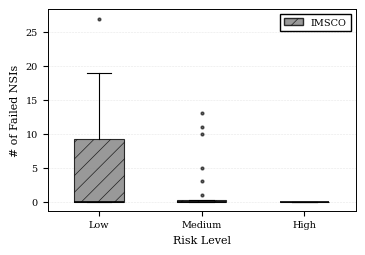

In [41]:
# %%
# %% [Célula: Boxplot de Falhas por Risco - Padrão IEEE (Fig 4)]

def carregar_dados_brutos_resiliencia(diretorio_pattern):
    dados_agrupados = {} 
    pastas = glob.glob(diretorio_pattern)
    
    for pasta in pastas:
        nome_pasta = os.path.basename(os.path.normpath(pasta))
        prefixo = nome_pasta.split('_')[0]
        nome_alg = NOME_ALGORITMOS_MAP.get(prefixo, prefixo)
        
        if nome_alg not in dados_agrupados:
            dados_agrupados[nome_alg] = {'Low': [], 'Medium': [], 'High': []}
            
        csvs = glob.glob(os.path.join(pasta, "*.csv"))
        for arquivo in csvs:
            try:
                df = pd.read_csv(arquivo)
                if 'affected_by_low_risk_node' in df.columns:
                    dados_agrupados[nome_alg]['Low'].append(df['affected_by_low_risk_node'].sum())
                    dados_agrupados[nome_alg]['Medium'].append(df['affected_by_med_risk_node'].sum())
                    dados_agrupados[nome_alg]['High'].append(df['affected_by_high_risk_node'].sum())
            except: pass
    return dados_agrupados

def plot_failures_boxplot_ieee(dados_raw):
    if not dados_raw: return

    # Labels limpos conforme pedido
    categorias = ['Low', 'Medium', 'High']
    mapa_csv = {'Low': 'Low', 'Medium': 'Medium', 'High': 'High'}
    
    algs_interesse = ['IMSCO'] 
    algoritmos = [alg for alg in algs_interesse if alg in dados_raw]
    
    fig, ax = plt.subplots(figsize=(3.5, 2.4))
    num_algs = len(algoritmos)
    box_width = 0.6 / num_algs
    x_base = np.arange(len(categorias))
    
    legend_elements = []
    
    for i, alg in enumerate(algoritmos):
        data_to_plot = []
        for cat in categorias:
            valores = dados_raw[alg][mapa_csv[cat]]
            data_to_plot.append(valores if valores else [0])
        
        posicoes = x_base + (i - (num_algs - 1) / 2) * box_width
        color = CORES_ALGORITMOS.get(alg, 'gray')
        hatch = HATCH_PATTERNS[i % len(HATCH_PATTERNS)]
        
        bp = ax.boxplot(data_to_plot, positions=posicoes, widths=box_width * 0.8, 
                        patch_artist=True, showfliers=True,
                        boxprops=dict(facecolor=color, color='black', alpha=0.8, linewidth=0.8),
                        capprops=dict(color='black', linewidth=0.8),
                        whiskerprops=dict(color='black', linewidth=0.8),
                        medianprops=dict(color='black', linewidth=1.2),
                        flierprops=dict(marker='o', markersize=2, markerfacecolor='black', alpha=0.6))
        
        for patch in bp['boxes']:
            patch.set_hatch(hatch)
            
        legend_elements.append(Patch(facecolor=color, hatch=hatch, edgecolor='black', label=alg, alpha=0.8))

    # Y-axis atualizado para NSIs
    ax.set_ylabel('# of Failed NSIs')
    # X-axis atualizado para Risk Level
    ax.set_xlabel('Risk Level')
    
    ax.set_xticks(x_base)
    ax.set_xticklabels(categorias)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    ax.legend(handles=legend_elements, loc='upper right', ncol=1, frameon=True, 
              fancybox=False, edgecolor='black', framealpha=1.0)
    
    plt.tight_layout(pad=0.2)
    plt.savefig('failures_boxplot_ieee.pdf', dpi=300)
    plt.show()

# Executa Boxplot
# Certifique-se de que a variável DIR_RESILIENT esteja definida corretamente no seu script
dados_brutos = carregar_dados_brutos_resiliencia(DIR_RESILIENT)
plot_failures_boxplot_ieee(dados_brutos)

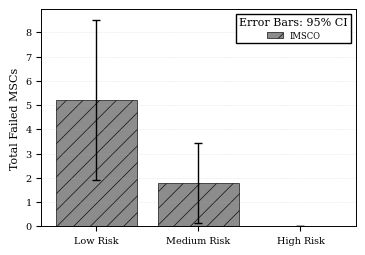

In [42]:
# %% [Célula: Gráfico com IC 95% e CORTE NO ZERO]
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import os
import scipy.stats as stats

# ==========================================
# 1. CONFIGURAÇÕES
# ==========================================
plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'lines.linewidth': 1.5,
    'axes.linewidth': 0.7,
    'grid.linewidth': 0.4,
    'font.family': 'serif',
    'text.usetex': False
})

# ==========================================
# 2. FUNÇÃO COM CORTE NO ZERO (ASSIMÉTRICA)
# ==========================================
def plot_failures_ci_clipped(dados_raw):
    if not dados_raw: return

    categorias = ['Low Risk', 'Medium Risk', 'High Risk']
    mapa_csv = {'Low Risk': 'Low', 'Medium Risk': 'Medium', 'High Risk': 'High'}
    
    algs_interesse = ['IMSCO'] 
    algoritmos = [alg for alg in algs_interesse if alg in dados_raw]
    
    fig, ax = plt.subplots(figsize=(3.5, 2.4))
    
    x = np.arange(len(categorias))
    total_width = 0.8
    bar_width = total_width / len(algoritmos)
    
    for i, alg in enumerate(algoritmos):
        means = []
        # Lista de listas para erro assimétrico: [[baixo, cima], [baixo, cima]...]
        asymmetric_errors = [] 
        
        for cat in categorias:
            valores = np.array(dados_raw[alg][mapa_csv[cat]])
            
            if len(valores) > 1:
                mu = np.mean(valores)
                sigma = np.std(valores, ddof=1)
                n = len(valores)
                
                # Cálculo do IC 95%
                sem = sigma / np.sqrt(n)
                h = sem * stats.t.ppf((1 + 0.95) / 2., n-1)
                
                means.append(mu)
                
                # --- CORREÇÃO DO ZERO ---
                # O erro para baixo não pode ser maior que a própria média (para não ficar negativo)
                lower_err = min(mu, h) 
                upper_err = h
                
                asymmetric_errors.append([lower_err, upper_err])
                
            elif len(valores) == 1:
                means.append(valores[0])
                asymmetric_errors.append([0, 0])
            else:
                means.append(0)
                asymmetric_errors.append([0, 0])
        
        # Matplotlib exige formato (2, N) para erros assimétricos -> Transpose (.T)
        yerr_plot = np.array(asymmetric_errors).T
        
        posicoes = x + (i - len(algoritmos)/2) * bar_width + bar_width/2
        color = CORES_ALGORITMOS.get(alg, 'gray')
        hatch = HACHURAS[i % len(HACHURAS)]
        
        ax.bar(posicoes, means, bar_width, 
               yerr=yerr_plot,    # Passamos o erro corrigido aqui
               capsize=3,
               error_kw={'elinewidth': 1, 'ecolor': 'black', 'capthick': 1},
               label=alg, color=color, hatch=hatch, edgecolor='black', alpha=0.9, linewidth=0.5)

    ax.set_ylabel('Total Failed MSCs')
    ax.set_xticks(x)
    ax.set_xticklabels(categorias)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Garante que o eixo Y comece estritamente no zero
    ax.set_ylim(bottom=0)
    
    ax.legend(
        loc='upper right',    
        ncol=1, 
        frameon=True, 
        fancybox=False, 
        edgecolor='black',
        fontsize=6,
        framealpha=1.0,
        title="Error Bars: 95% CI"
    )
    
    plt.tight_layout(pad=0.2)
    plt.savefig('failures_ci_clipped_ieee.pdf', dpi=300)
    plt.show()

# Execução
if 'dados_brutos' in locals():
    plot_failures_ci_clipped(dados_brutos)
else:
    dados_brutos = carregar_dados_brutos_resiliencia(DIR_RESILIENT)
    plot_failures_ci_clipped(dados_brutos)